# ****AB-тест "paymentChange" — Анализ данных выводы****


## Введение

Проводится анализ A/B-эксперимента "paymentChange" в мобильном приложении с мотивирующими цитатами.

Цель — оценить влияние снижения стоимости подписки (400 → 160 у.е.).

Данные включают исторические действия и платежи пользователей, а также экспериментальные данные.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import itertools


import scipy.stats as sps
from scipy.stats import ttest_ind, chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.multitest import multipletests


In [ ]:
sns.set_theme(style="whitegrid")

PALETTE = {
    "control": "#4C72B0",
    "test": "#DD8452"
}

plt.rcParams.update({
    "figure.figsize": (15, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "font.size": 11,
    "legend.fontsize": 11,
    "axes.titleweight": "bold"
})

# Предэкспериментальный анализ


# 1. Анализ поведения пользователей до эксперимента

In [ ]:
df_act_hist = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/АБ дизайн/action_hist.csv')


In [ ]:
df_act_hist.head()


,uid,Ts,Action
0,aaaaw,2019-11-26 21:48:12.053588,firstOpen
1,aaaaw,2019-11-27 08:03:10.759203,function1
2,aaacj,2019-11-29 16:14:23.163530,firstOpen
3,aaacj,2019-11-30 02:12:40.876643,function3
4,aaacj,2019-11-30 03:01:45.242326,function4


Action = firstOpen – событие первого входа пользователя в продукт.

Action = functionX – факты взаимодействия пользователя с фичами продукта, где X – id конкретной фичи.


In [ ]:
df_act_hist.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131449 entries, 0 to 131448
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   uid     131449 non-null  object
 1   Ts      131449 non-null  object
 2   Action  131449 non-null  object
dtypes: object(3)
memory usage: 3.0+ MB


In [ ]:
df_act_hist.describe()


,uid,Ts,Action
count,131449,131449,131449
unique,50000,131449,5
top,zsiye,2019-11-24 03:20:20.451798,firstOpen
freq,5,1,50000


In [ ]:
df_act_hist['Ts'] = pd.to_datetime(df_act_hist['Ts'])

df_act_hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131449 entries, 0 to 131448
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   uid     131449 non-null  object        
 1   Ts      131449 non-null  datetime64[ns]
 2   Action  131449 non-null  object        
dtypes: datetime64[ns](1), object(2)
memory usage: 3.0+ MB


In [ ]:
df_act_hist.describe()

,Ts
count,131449
mean,2019-11-25 02:42:29.510419456
min,2019-11-19 00:00:04.954457
25%,2019-11-22 04:19:59.871841024
50%,2019-11-25 02:46:06.394972928
75%,2019-11-28 01:10:12.519314944
max,2019-11-30 23:59:52.578446


In [ ]:
df_act_hist.duplicated().sum()

np.int64(0)

In [ ]:
# наименование уникальных событий

df_act_hist['Action'].unique()


array(['firstOpen', 'function1', 'function3', 'function4', 'function2'],
      dtype=object)

In [ ]:
df_act_hist = df_act_hist.sort_values(by=['uid','Ts'])


## 1.1. Пользователи и активность

In [ ]:
# Количество уникальных пользователей

df_act_hist['uid'].nunique()


50000

In [ ]:
# Количество новых пользователей

df_act_hist.query('Action == "firstOpen"').uid.nunique()


50000

In [ ]:
# Среднее количество событий на пользователя

count_action_uid = df_act_hist.groupby('uid', as_index=False)\
                              .agg({'Action':'count'})

count_action_uid.describe(percentiles=[0.9, 0.95, 0.99]).round(2)


,Action
count,50000.00
mean,2.63
std,0.65
min,1.00
50%,3.00
90%,3.00
95%,4.00
99%,4.00
max,5.00


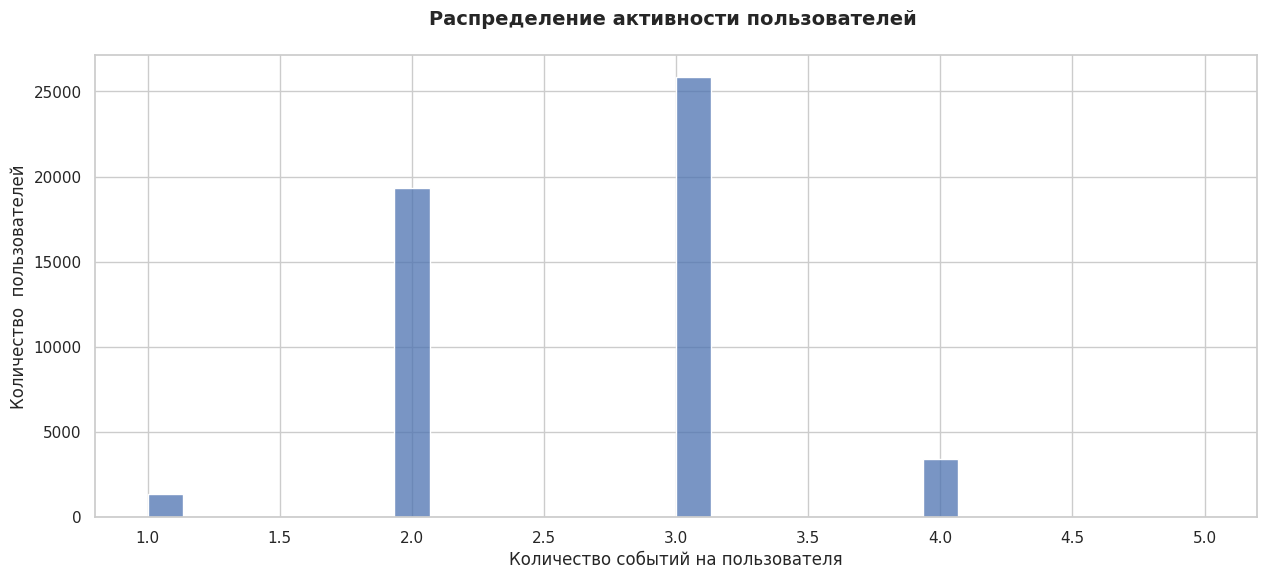

In [ ]:
# количество событий на пользователя

ax = sns.histplot(
    count_action_uid['Action'],
    color=PALETTE["control"],
    bins=30
)
ax.set_xlabel('Количество событий на пользователя')
ax.set_ylabel('Количество  пользователей')
ax.set_title('Распределение активности пользователей \n')

plt.show()

Вывод по активности пользователей:

- Среднее количество действий на пользователя = 2.63
- Медиана = 3
- 99% пользователей совершают не более 4 действий
- Максимум = 5 действий


In [ ]:
# Популярность функций продукта среди пользователей

df_act_hist.groupby('Action', as_index=False)\
           .agg(user_count = ('uid','nunique'))\
           .assign(percent = lambda x: (x['user_count']/  x.loc[x['Action']=='firstOpen','user_count'].iloc[0] * 100)).round(2)


,Action,user_count,percent
0,firstOpen,50000,100.00
1,function1,10010,20.02
2,function2,12276,24.55
3,function3,22168,44.34
4,function4,36995,73.99


In [ ]:
# пользовательский путь пользователя от firstOpen

actions_order = ['firstOpen', 'function1', 'function2', 'function3', 'function4']

df_paths = df_act_hist[df_act_hist['Action'].isin(actions_order)] \
                                            .sort_values(['uid', 'Ts']) \
                                            .groupby('uid')['Action'].apply(list).reset_index()

user_paths = []

for _, row in df_paths.iterrows():
    uid = row['uid']
    actions = row['Action']
    if 'firstOpen' in actions:
        first_idx = actions.index('firstOpen')
        path = actions[first_idx:]
        user_paths.append({'uid': uid, 'Path': ' → '.join(path)})

user_paths_df = pd.DataFrame(user_paths)

pd.set_option('display.max_colwidth', None)

path_counts = user_paths_df.groupby('Path', as_index=False).uid.nunique().sort_values(by='uid', ascending=False)

total_users = df_act_hist[df_act_hist['Action'] == 'firstOpen']['uid'].nunique()

path_counts['percent'] = (path_counts['uid'] / total_users * 100).round(2)

path_counts


,Path,uid,percent
15,firstOpen → function4,14257,28.51
14,firstOpen → function3 → function4,12178,24.36
12,firstOpen → function2 → function4,4301,8.60
8,firstOpen → function1 → function4,3168,6.34
10,firstOpen → function2 → function3,2761,5.52
13,firstOpen → function3,2140,4.28
6,firstOpen → function1 → function3,2039,4.08
11,firstOpen → function2 → function3 → function4,1512,3.02
9,firstOpen → function2,1489,2.98
1,firstOpen → function1,1458,2.92


Вывод по популярности функций:

- 74% пользователей используют function4 — это наиболее востребованная функция
- Только 20–25% доходят до function1 и function2

Пользователи явно «скачут» сразу к более ценным или заметным функциям, а не проходят линейно от 1 → 2 → 3 → 4.

**Пути пользователей:**
- Самый популярный путь — firstOpen → function4 - 28,5% пользователей сразу открывают function4 после входа.
- Второй по популярности путь — firstOpen → function3 → function4 - 24,4% пользователей проходит через function3 к function4.
- Значительная часть пользователей пропускают function1.
- Полный путь firstOpen → function1 → function2 → function3 → function4 встречается только у 28 пользователей (0,06%).
- Пути из трёх функций занимают небольшую долю пользователей (<7%).

**Итого:**
- Пользователи ориентируются на ключевую ценность, а не на линейное прохождение функций.

- function4 — центральная функция продукта, вокруг которой строятся большинство действий.

- function1 и function2 скорее вспомогательные — не все пользователи проходят через них.


## 1.2. Временные показатели активности пользователей

In [ ]:
# Расчёт времени от первого входа пользователя до каждого последующего действия (в часах) пользователя

df_act_hist['open_ts'] = df_act_hist.groupby('uid', as_index=False)['Ts'].transform('min')

df_act_hist['delta_ts'] = df_act_hist['Ts'] - df_act_hist['open_ts']

df_act_hist['delta_hours'] =  (df_act_hist['delta_ts'].dt.total_seconds() / 3600).round(2)

df_act_hist.head()

,uid,Ts,Action,open_ts,delta_ts,delta_hours
0,aaaaw,2019-11-26 21:48:12.053588,firstOpen,2019-11-26 21:48:12.053588,0 days 00:00:00,0.00
1,aaaaw,2019-11-27 08:03:10.759203,function1,2019-11-26 21:48:12.053588,0 days 10:14:58.705615,10.25
2,aaacj,2019-11-29 16:14:23.163530,firstOpen,2019-11-29 16:14:23.163530,0 days 00:00:00,0.00
3,aaacj,2019-11-30 02:12:40.876643,function3,2019-11-29 16:14:23.163530,0 days 09:58:17.713113,9.97
4,aaacj,2019-11-30 03:01:45.242326,function4,2019-11-29 16:14:23.163530,0 days 10:47:22.078796,10.79


In [ ]:
df_act_hist.groupby('Action')['delta_hours'].describe().round(2).reset_index()


,Action,count,mean,std,min,25%,50%,75%,max
0,firstOpen,50000.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,function1,10010.0,6.51,4.53,0.02,2.94,6.24,9.60,24.28
2,function2,12276.0,7.72,5.55,0.02,3.62,7.12,10.98,38.80
3,function3,22168.0,8.95,6.27,0.02,4.29,8.20,12.63,43.42
4,function4,36995.0,11.14,7.16,0.02,5.82,10.32,15.62,50.96


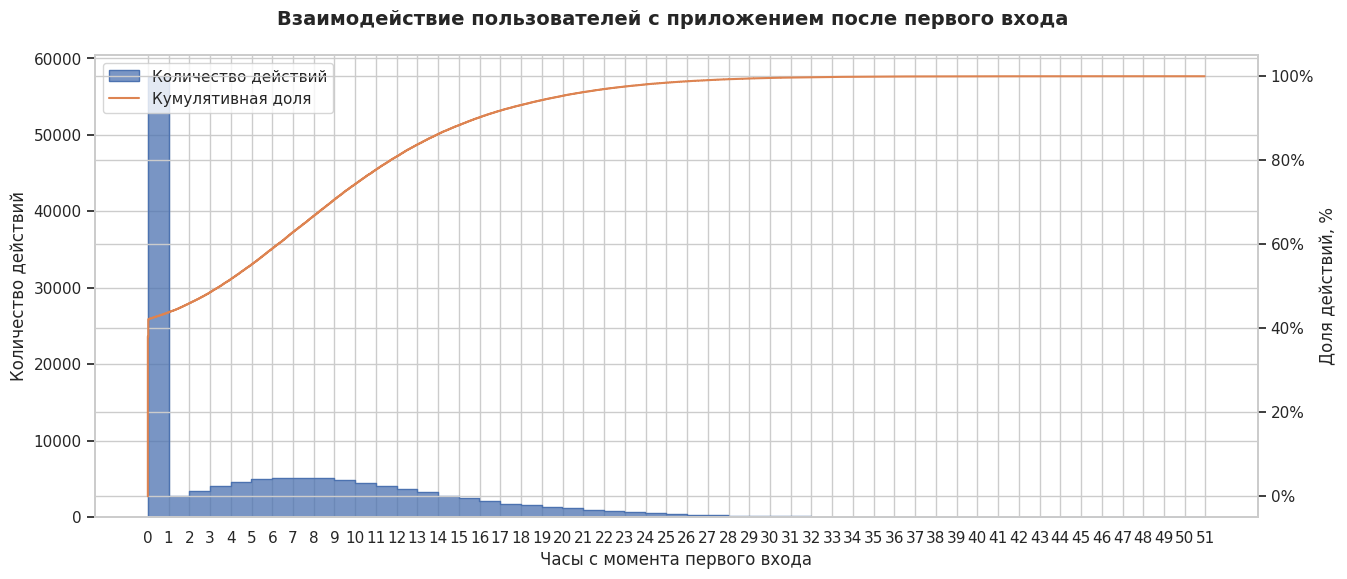

In [ ]:
# Гистограмма: количество действий за каждый час
# CDF: доля действий, совершённых к определённому часу

ax = sns.histplot(
    df_act_hist,
    x='delta_hours',
    binwidth=1,
    element='step',
    stat='count',
    color=PALETTE["control"],
    label='Количество действий'
)

delta_sorted = np.sort(df_act_hist['delta_hours'])
cdf = np.arange(1, len(delta_sorted)+1) / len(delta_sorted)

ax2 = ax.twinx()
ax2.plot(delta_sorted, cdf, color=PALETTE["test"], label='Кумулятивная доля')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1))

ax.set_xlabel('Часы с момента первого входа')
ax.set_ylabel('Количество действий')
ax2.set_ylabel('Доля действий, %')

max_hour = int(df_act_hist['delta_hours'].max()) + 1
ax.set_xticks(range(0, max_hour+1, 1))

lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Взаимодействие пользователей с приложением после первого входа \n')
plt.show()

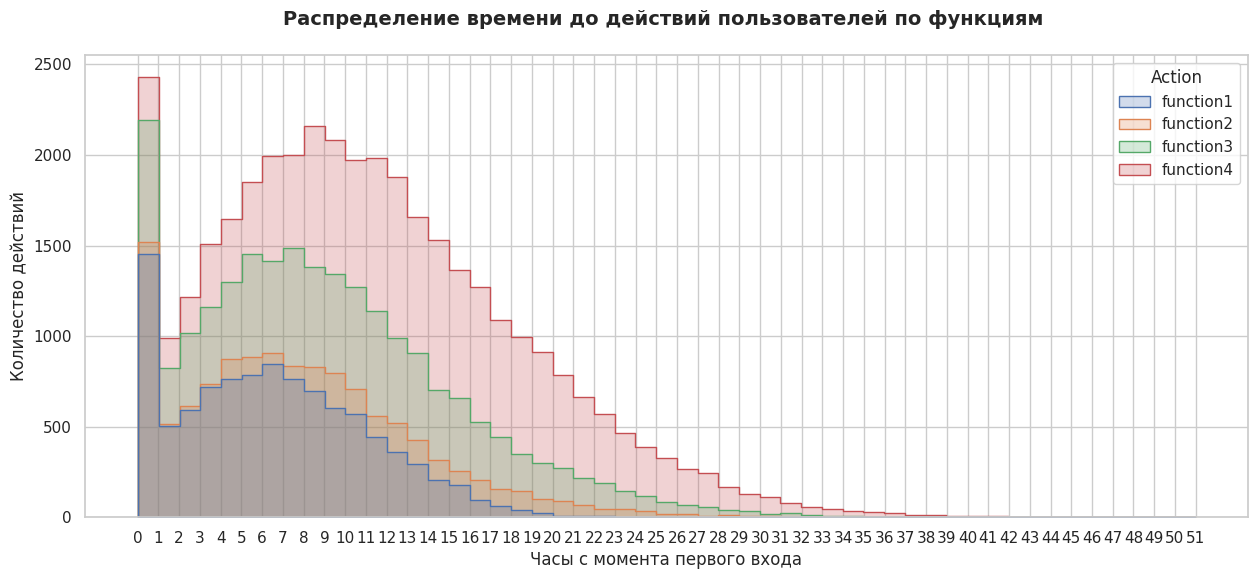

In [ ]:
# время от первого входа до каждого действия, распределение по функциям

actions_order = ['function1', 'function2', 'function3', 'function4']

df_plot = df_act_hist[df_act_hist['Action'].isin(actions_order)].copy()

palette_actions = {
    'function1': PALETTE["control"],
    'function2': PALETTE["test"],
    'function3': '#55a868',
    'function4': '#c44e52',
}

ax = sns.histplot(
    data=df_plot,
    x='delta_hours',
    hue='Action',
    hue_order=actions_order,
    palette=palette_actions,
    binwidth=1,
    element='step',
    stat='count',
    common_norm=False
)

max_hour = int(df_plot['delta_hours'].max()) + 1
ax.set_xticks(np.arange(0, max_hour+1, 1))

ax.set_xlabel('Часы с момента первого входа')
ax.set_ylabel('Количество действий')
ax.set_title('Распределение времени до действий пользователей по функциям \n')

plt.show()

In [ ]:
# Анализ времени между последовательными действиями пользователя

df_act_hist['prev_ts'] = df_act_hist.groupby('uid', as_index=False)['Ts'].shift(1)

df_act_hist['delta_prev_ts'] = df_act_hist['Ts'] - df_act_hist['prev_ts']

df_act_hist['delta_prev_hours'] =  df_act_hist['delta_prev_ts'].dt.total_seconds() / 3600

df_act_hist.groupby('Action')['delta_prev_hours'].describe().round(2).reset_index()


,Action,count,mean,std,min,25%,50%,75%,max
0,firstOpen,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,function1,10010.0,6.50,4.53,0.02,2.94,6.24,9.60,24.28
2,function2,12276.0,6.55,4.55,0.02,2.97,6.28,9.66,26.31
3,function3,22168.0,6.55,4.54,0.02,2.95,6.27,9.67,27.90
4,function4,36995.0,6.57,4.55,0.02,2.94,6.33,9.69,27.90


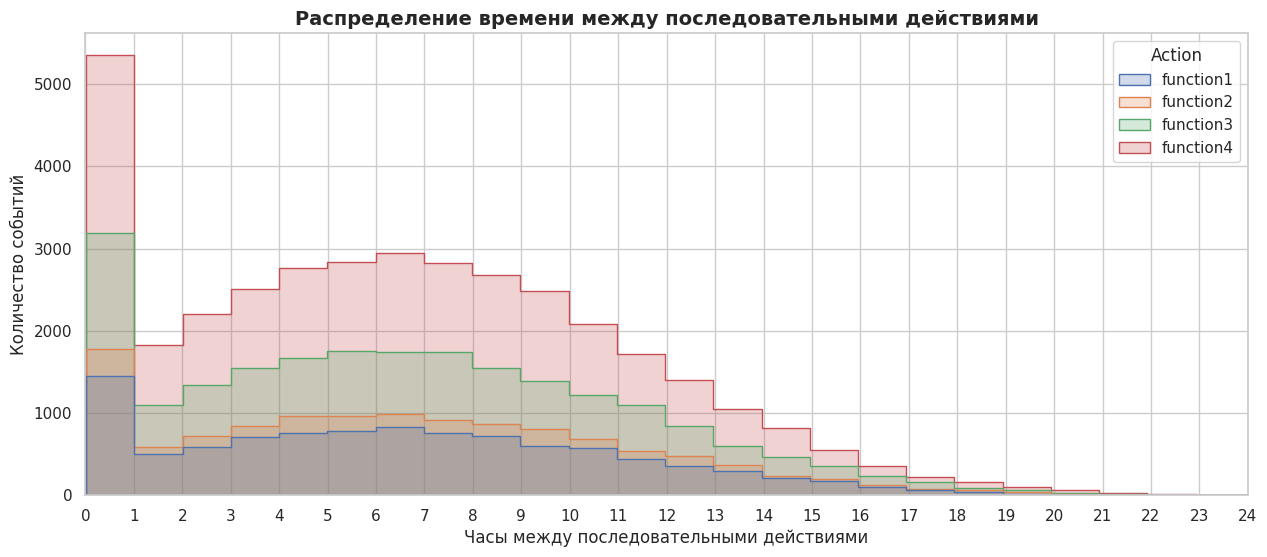

In [ ]:
# Время между последовательными действиями пользователей, распределение по функциям

actions_order = ['function1', 'function2', 'function3', 'function4']

df_plot = df_act_hist[
    (df_act_hist['Action'].isin(actions_order)) &
    (df_act_hist['delta_prev_hours'].notna())
].copy()

palette = {
    'function1': PALETTE["control"],
    'function2': PALETTE["test"],
    'function3': '#55A868',
    'function4': '#C44E52',
}

ax = sns.histplot(
    data=df_plot,
    x='delta_prev_hours',
    hue='Action',
    hue_order=actions_order,
    palette=palette,
    binwidth=1,
    element='step',
    stat='count',
    common_norm=False
)

ax.set_xlim(0, 24)
ax.set_xticks(np.arange(0, 25, 1))

ax.set_xlabel('Часы между последовательными действиями')
ax.set_ylabel('Количество событий')
ax.set_title('Распределение времени между последовательными действиями')

plt.show()



1. Время от первого входа до действия (delta_hours)

* 60% действий совершается в первые 6 часов после первого входа.
* К 11 - 12 часам совершается 80% действий после первого входа.
* После 20 часов график времени выходит на плато — оставшиеся действия происходят редко.
* Среднее время до действий:
Функции function3 и function4 происходят позже в среднем 9–11 часов, а function1 и function2 раньше - 6–8 часов.

2. Время между последовательными действиями (delta_prev_hours)

* Средний интервал между действиями составляет в среднем 6,5 часов, медиана близка к среднему.
* Основной диапазон активности — 2–10 часов.

Вывод:

Основная масса пользователей активна в первые 6–8 часов, затем активность снижается.

Переходы между функциями хаотичны, но временной интервал между действиями стабилен в среднем 6–7 часов.



# 2. Анализ покупок пользователей до эксперимента

In [ ]:
df_pay_hist = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/АБ дизайн/payments_hist.csv')

In [ ]:
df_pay_hist.head()

,uid,paymentType,Payment
0,pkyhd,type1,400
1,auben,type1,400
2,ahcar,type2,200
3,ummyb,type2,200
4,lprbt,type2,200


paymentType = type1 – покупка подписки. На истории была только 400.

paymentType = type2 – разовая покупка. Всегда 200.


In [ ]:
df_pay_hist.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27532 entries, 0 to 27531
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   uid          27532 non-null  object
 1   paymentType  27532 non-null  object
 2   Payment      27532 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 645.4+ KB


In [ ]:
df_pay_hist.describe().round(2)

,Payment
count,27532.00
mean,273.00
std,96.29
min,200.00
25%,200.00
50%,200.00
75%,400.00
max,400.00


In [ ]:
# Уникальные данные типа платежа

df_pay_hist.paymentType.unique()


array(['type1', 'type2'], dtype=object)

## 2.1. Общие показатели платежей

In [ ]:
# количество платящих пользователей

df_pay_hist.uid.nunique()


25000

In [ ]:
# Количество пользователей по каждому типу платежа

df_pay_hist.groupby('paymentType').uid.count()


,uid
paymentType,
type1,10049
type2,17483


In [ ]:
# общая выручка

print('revenue = ',df_pay_hist.Payment.sum())


revenue =  7516200


In [ ]:
# средний чек на транзакцию (AOV),

print('AOV = ',df_pay_hist.Payment.mean().round(2))

AOV =  273.0


In [ ]:
# ARPPU — средний доход на платящего пользователя

print('ARPPU = ', df_pay_hist.groupby('uid').Payment.sum().mean())


ARPPU =  300.648


Разрыв между ARPPU и AOV небольшой примерно 10%, значит средний платёж на пользователя не сильно отличается от среднего чека транзакции.

## 2.2. Структура платежей

In [ ]:
# уникальные суммы покупок

df_pay_hist.groupby('uid', as_index=False)\
           .Payment.sum()\
           .Payment.unique()

array([200, 400, 600])

In [ ]:
df_pay_hist_pivot = df_pay_hist.pivot_table(index='uid',
                                            columns='paymentType',
                                            values='Payment',
                                            aggfunc='count',
                                            fill_value=0).reset_index()

df_pay_hist_pivot.head()

paymentType,uid,type1,type2
0,aaaaw,0,1
1,aaacj,1,0
2,aaczh,0,1
3,aadfq,1,0
4,aadge,1,1


In [ ]:
# уникальное сочетание типов платежей

unique_combinations = df_pay_hist_pivot[['type1','type2']].drop_duplicates()

unique_combinations


paymentType,type1,type2
0,0,1
1,1,0
4,1,1


In [ ]:
# доля пользователей каждого типа платежей

df_pay_hist_pivot.groupby(['type1','type2'], as_index=False)\
                 .agg(num_users =('uid', 'nunique'))\
                 .assign(percent = lambda x: (x['num_users'] / x['num_users'].sum()) * 100).round(2)


,type1,type2,num_users,percent
0,0,1,14951,59.80
1,1,0,7517,30.07
2,1,1,2532,10.13


In [ ]:
# добавим столбец с указанием сегмента плательщика

df_pay_hist_pivot['segment_code'] = (
    df_pay_hist_pivot['type1'].gt(0).astype(int).astype(str)
    + '_'
    + df_pay_hist_pivot['type2'].gt(0).astype(int).astype(str)
)

df_pay_hist_pivot['segment_name'] = df_pay_hist_pivot['segment_code'].map({
    '1_0': 'Только подписка',
    '0_1': 'Только разовые покупки',
    '1_1': 'Подписка + разовая'

})

df_pay_hist_pivot.head()

paymentType,uid,type1,type2,segment_code,segment_name
0,aaaaw,0,1,0_1,Только разовые покупки
1,aaacj,1,0,1_0,Только подписка
2,aaczh,0,1,0_1,Только разовые покупки
3,aadfq,1,0,1_0,Только подписка
4,aadge,1,1,1_1,Подписка + разовая


In [ ]:

df_pay_hist = df_pay_hist.merge(df_pay_hist_pivot[['uid', 'segment_name']], on='uid', how='left')

df_pay_hist.head()


,uid,paymentType,Payment,segment_name
0,pkyhd,type1,400,Подписка + разовая
1,auben,type1,400,Только подписка
2,ahcar,type2,200,Только разовые покупки
3,ummyb,type2,200,Только разовые покупки
4,lprbt,type2,200,Подписка + разовая


In [ ]:
df_pay_hist.shape

(27532, 4)

In [ ]:
# Доли пользователей и выручки по сегментам

segment_summary = df_pay_hist.groupby('segment_name', as_index=False)\
                            .agg(users=('uid','nunique'), segment_sum=('Payment','sum'))\
                            .assign(user_percent=lambda x: (x['users']/x['users'].sum()*100).round(2),
                                    revenue_share=lambda x: (x['segment_sum']/x['segment_sum'].sum()*100).round(2))

segment_summary


,segment_name,users,segment_sum,user_percent,revenue_share
0,Подписка + разовая,2532,1519200,10.13,20.21
1,Только подписка,7517,3006800,30.07,40.00
2,Только разовые покупки,14951,2990200,59.80,39.78


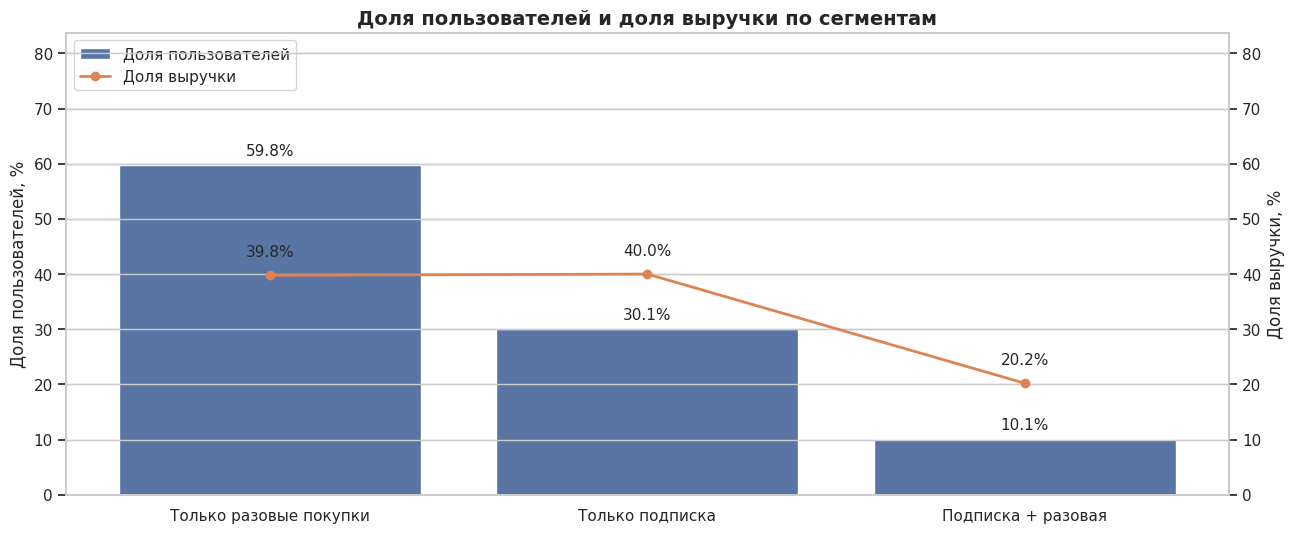

In [ ]:
# Доля пользователей и доля выручки по сегментам'

segment_summary_sorted = segment_summary.sort_values('user_percent', ascending=False)

fig, ax1 = plt.subplots()

# --- Столбцы: доля пользователей ---
sns.barplot(
    data=segment_summary_sorted,
    x='segment_name',
    y='user_percent',
    color=PALETTE["control"],
    ax=ax1,
    label='Доля пользователей'
)

ax1.set_ylabel('Доля пользователей, %')
ax1.set_xlabel('')

y_max = max(
    segment_summary_sorted['user_percent'].max(),
    segment_summary_sorted['revenue_share'].max()
) * 1.4

ax1.set_ylim(0, y_max)

# Подписи столбцов
for i, v in enumerate(segment_summary_sorted['user_percent']):
    ax1.text(i, v + y_max*0.02, f"{v:.1f}%", ha='center')

# --- Линия: доля выручки ---
ax2 = ax1.twinx()

line = ax2.plot(
    segment_summary_sorted['segment_name'],
    segment_summary_sorted['revenue_share'],
    color=PALETTE["test"],
    marker='o',
    linewidth=2,
    label='Доля выручки'
)

ax2.set_ylabel('Доля выручки, %')
ax2.set_ylim(0, y_max)

# Подписи точек
for i, v in enumerate(segment_summary_sorted['revenue_share']):
    ax2.text(i, v + y_max*0.04, f"{v:.1f}%", ha='center')

# --- Легенда ---
lines_labels = ax1.get_legend_handles_labels()
lines2_labels = ax2.get_legend_handles_labels()
ax1.legend(lines_labels[0] + lines2_labels[0], lines_labels[1] + lines2_labels[1], loc='upper left')

ax1.set_title('Доля пользователей и доля выручки по сегментам')

plt.show()

In [ ]:
# метрики по сегменту

segment_metrics = df_pay_hist.groupby('segment_name').agg(
    total_revenue=('Payment', 'sum'),               # общая выручка сегмента
    paying_users=('uid', 'nunique'),                # количество платящих пользователей
    total_payments=('Payment', 'count')             # количество платежей
).reset_index()

segment_metrics['AOV'] = segment_metrics['total_revenue'] / segment_metrics['total_payments']
segment_metrics['ARPPU'] = segment_metrics['total_revenue'] / segment_metrics['paying_users']

# Округляем
segment_metrics[['AOV', 'ARPPU',]] = segment_metrics[['AOV', 'ARPPU',]].round(2)

segment_metrics

,segment_name,total_revenue,paying_users,total_payments,AOV,ARPPU
0,Подписка + разовая,1519200,2532,5064,300.0,600.0
1,Только подписка,3006800,7517,7517,400.0,400.0
2,Только разовые покупки,2990200,14951,14951,200.0,200.0


1. Общая активность платящих пользователей:

* Всего платящих пользователей: 25 000.

* Всего платежей: 27 532 (учитывая, что один пользователь может совершать несколько покупок).

* Общая выручка: 7 516 тыс. руб.

* Средний чек (AOV) на платеж: 273 руб.

* Средний доход на платящего пользователя (ARPPU): 301 руб.

Средний доход на пользователя немного выше среднего чека, скорее всего, объясняется тем, что некоторые пользователи сначала делают разовую покупку, а затем оформляют подписку.

2. Платежи по типам и сегментам пользователей:

* 60% пользователей делает только разовые покупки, что обеспечивает около 40% выручки.

* Подписка привлекательна для 30% пользователей, при этом она генерирует 40% выручки, что делает её более ценным источником дохода на одного пользователя.

* Комбинированные покупки встречаются редко 10%, но приносят значимую долю выручки — 20%, что указывает на высокую ценность этих пользователей для бизнеса.

По сегментам:

* Сегмент “Подписка + разовая” приносит максимальный доход на пользователя и демонстрирует высокую вовлечённость (повторные платежи).
* Сегмент “Только подписка” стабилен.
* Сегмент “Только разовые покупки” самый массовый, но с низким доходом на пользователя — здесь стратегически важно конвертировать пользователей в подписку или стимулировать повторные покупки.

Вывод:

Подписка приносит большую ценность на пользователя, несмотря на меньшее количество клиентов.

Разовые покупки популярны по числу пользователей, но каждая транзакция ниже по сумме.

Комбинированные пользователи — стратегически важный сегмент: высокий LTV потенциал.

В целом, стратегия роста выручки должна фокусироваться на увеличении конверсии пользователей в подписку.

# 3. Анализ взаимодействия с функциями в разрезе сегментов пользователей по типу платежей

In [ ]:
df_act_hist.head()

,uid,Ts,Action,open_ts,delta_ts,delta_hours,prev_ts,delta_prev_ts,delta_prev_hours
0,aaaaw,2019-11-26 21:48:12.053588,firstOpen,2019-11-26 21:48:12.053588,0 days 00:00:00,0.00,NaT,NaT,NaN
1,aaaaw,2019-11-27 08:03:10.759203,function1,2019-11-26 21:48:12.053588,0 days 10:14:58.705615,10.25,2019-11-26 21:48:12.053588,0 days 10:14:58.705615,10.249640
2,aaacj,2019-11-29 16:14:23.163530,firstOpen,2019-11-29 16:14:23.163530,0 days 00:00:00,0.00,NaT,NaT,NaN
3,aaacj,2019-11-30 02:12:40.876643,function3,2019-11-29 16:14:23.163530,0 days 09:58:17.713113,9.97,2019-11-29 16:14:23.163530,0 days 09:58:17.713113,9.971587
4,aaacj,2019-11-30 03:01:45.242326,function4,2019-11-29 16:14:23.163530,0 days 10:47:22.078796,10.79,2019-11-30 02:12:40.876643,0 days 00:49:04.365683,0.817879


In [ ]:
df_act_hist.shape

(131449, 9)

In [ ]:
df_pay_hist.head()

,uid,paymentType,Payment,segment_name
0,pkyhd,type1,400,Подписка + разовая
1,auben,type1,400,Только подписка
2,ahcar,type2,200,Только разовые покупки
3,ummyb,type2,200,Только разовые покупки
4,lprbt,type2,200,Подписка + разовая


In [ ]:
df_pay_hist.shape

(27532, 4)

In [ ]:
# агрегация платежей на  пользователя

df_pay_user = df_pay_hist.groupby('uid', as_index=False)\
                        .agg(Payment=('Payment', 'sum'),
                             segment_name=('segment_name', 'first'))



In [ ]:
df = df_act_hist.merge(df_pay_user[['uid', 'Payment', 'segment_name']], on='uid', how='left')

df.head()

,uid,Ts,Action,open_ts,delta_ts,delta_hours,prev_ts,delta_prev_ts,delta_prev_hours,Payment,segment_name
0,aaaaw,2019-11-26 21:48:12.053588,firstOpen,2019-11-26 21:48:12.053588,0 days 00:00:00,0.00,NaT,NaT,NaN,200.0,Только разовые покупки
1,aaaaw,2019-11-27 08:03:10.759203,function1,2019-11-26 21:48:12.053588,0 days 10:14:58.705615,10.25,2019-11-26 21:48:12.053588,0 days 10:14:58.705615,10.249640,200.0,Только разовые покупки
2,aaacj,2019-11-29 16:14:23.163530,firstOpen,2019-11-29 16:14:23.163530,0 days 00:00:00,0.00,NaT,NaT,NaN,400.0,Только подписка
3,aaacj,2019-11-30 02:12:40.876643,function3,2019-11-29 16:14:23.163530,0 days 09:58:17.713113,9.97,2019-11-29 16:14:23.163530,0 days 09:58:17.713113,9.971587,400.0,Только подписка
4,aaacj,2019-11-30 03:01:45.242326,function4,2019-11-29 16:14:23.163530,0 days 10:47:22.078796,10.79,2019-11-30 02:12:40.876643,0 days 00:49:04.365683,0.817879,400.0,Только подписка


In [ ]:
df.shape

(131449, 11)

In [ ]:
df.uid.nunique()

50000

In [ ]:
df.segment_name.unique()

array(['Только разовые покупки', 'Только подписка', nan,
       'Подписка + разовая'], dtype=object)

In [ ]:
df['segment_name'] = df['segment_name'].fillna('Без платежей')
df['Payment'] = df['Payment'].fillna(0)

In [ ]:
# Kоличество уникальных пользователей в каждом сегменте и их доля от общей численности.

df_segment = df.groupby('segment_name', as_index=False)\
                .agg(count_user=('uid', 'nunique'))\
                .assign(percent = lambda x: (x['count_user'] / x['count_user'].sum() * 100).round(2))\
                .sort_values(by=('percent'))

df_segment

,segment_name,count_user,percent
1,Подписка + разовая,2532,5.06
2,Только подписка,7517,15.03
3,Только разовые покупки,14951,29.90
0,Без платежей,25000,50.00


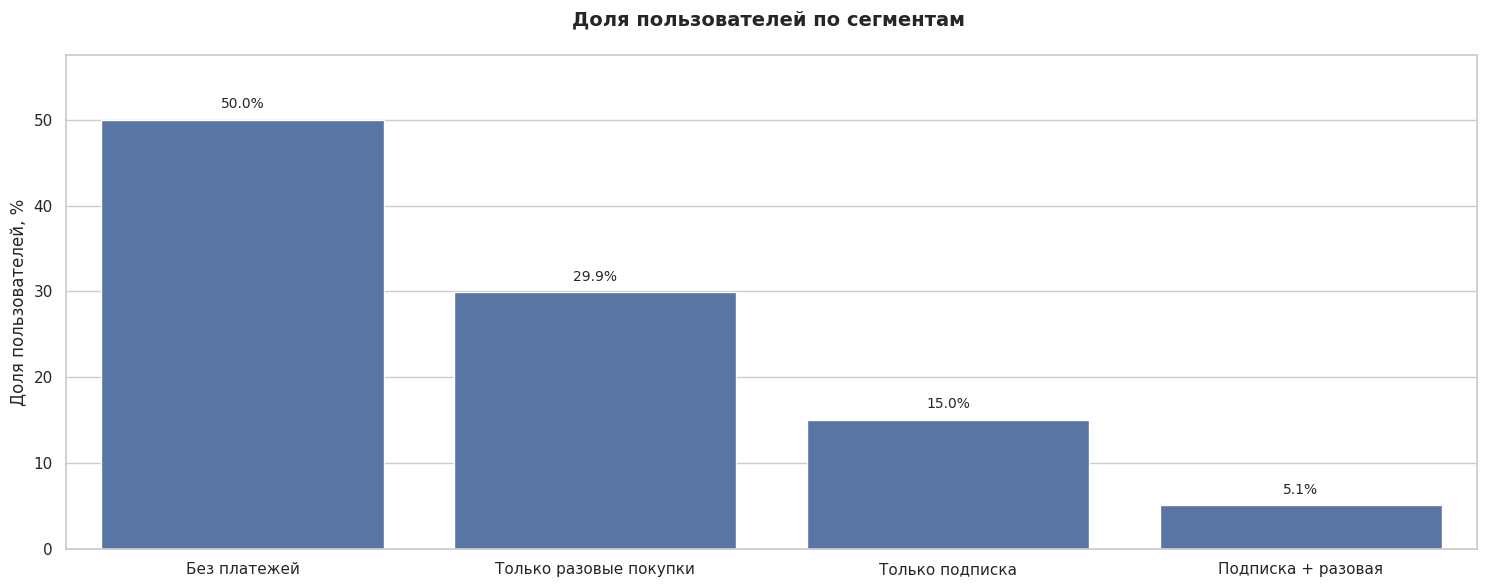

In [ ]:
ax = sns.barplot(
    data=df_segment,
    x='segment_name',
    y='percent',
    color=PALETTE["control"],
    order=df_segment.sort_values('percent', ascending=False)['segment_name']
)

plt.ylabel('Доля пользователей, %')
plt.xlabel('')
plt.title('Доля пользователей по сегментам \n')

max_value = df_segment['percent'].max()
ax.set_ylim(0, max_value * 1.15)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}%',
                (p.get_x() + p.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=10,
                xytext=(0, 6),
                textcoords='offset points')

plt.tight_layout()
plt.show()


In [ ]:
# Группировка по сегменту и функциям + среднее время avg_delta_hours — среднее время от первого входа до действия
                                                 # avg_delta_prev_hours — среднее время между предыдущим и текущим действием

df_grouped = df.groupby(['segment_name', 'Action'])\
              .agg(count_user = ('uid', 'nunique'),\
                  avg_delta_hours = ('delta_hours' , 'mean'),\
                  avg_delta_prev_hours = ('delta_prev_hours', 'mean')).round(2)

# Доля пользователей каждого сегмента, дошедших до каждой функции относительно всех пользователей сегмента.

df_grouped['percent'] = df_grouped.groupby('segment_name')['count_user']\
                                  .transform(lambda x: (x / x.iloc[0] * 100).round(2))

df_grouped

count_user  avg_delta_hours  \
segment_name           Action                                   
Без платежей           firstOpen       25000             0.00   
                       function1        5045             6.48   
                       function2        6133             7.72   
                       function3       11012             8.95   
                       function4       18447            11.12   
Подписка + разовая     firstOpen        2532             0.00   
                       function1         485             6.49   
                       function2         657             7.23   
                       function3        1118             8.97   
                       function4        1881            10.98   
Только подписка        firstOpen        7517             0.00   
                       function1        1505             6.60   
                       function2        1846             7.87   
                       function3        3339             8.96   
                       function4        5555            11.12   
Только разовые покупки firstOpen       14951             0.00   
                       function1        2975             6.51   
                       function2        3640             7.74   
                       function3        6699             8.94   
                       function4       11112            11.22   

                                  avg_delta_prev_hours  percent  
segment_name           Action                                    
Без платежей           firstOpen                   NaN   100.00  
                       function1                  6.48    20.18  
                       function2                  6.51    24.53  
                       function3                  6.55    44.05  
                       function4                  6.57    73.79  
Подписка + разовая     firstOpen                   NaN   100.00  
                       function1                  6.48    19.15  
                       function2                  6.23    25.95  
                       function3                  6.53    44.15  
                       function4                  6.47    74.29  
Только подписка        firstOpen                   NaN   100.00  
                       function1                  6.60    20.02  
                       function2                  6.65    24.56  
                       function3                  6.47    44.42  
                       function4                  6.55    73.90  
Только разовые покупки firstOpen                   NaN   100.00  
                       function1                  6.51    19.90  
                       function2                  6.61    24.35  
                       function3                  6.58    44.81  
                       function4                  6.58    74.32

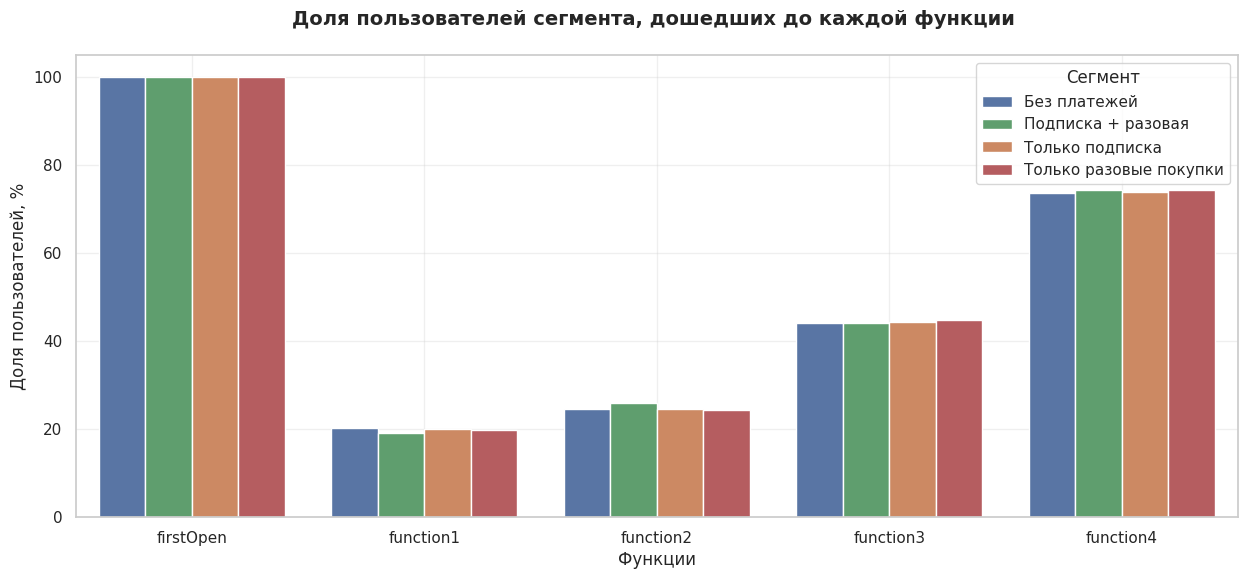

In [ ]:

PALETTE_SEGMENTS = {
    'Без платежей': '#4C72B0',
    'Только подписка': '#DD8452',
    'Подписка + разовая': '#55A868',
    'Только разовые покупки': '#C44E52'
}

sns.barplot(
    data=df_grouped.reset_index(),
    x='Action',
    y='percent',
    hue='segment_name',
    palette=PALETTE_SEGMENTS
)

plt.title('Доля пользователей сегмента, дошедших до каждой функции \n')
plt.ylabel('Доля пользователей, %')
plt.xlabel('Функции')
plt.grid(True, alpha=0.3)
plt.legend(title='Сегмент')
plt.show()


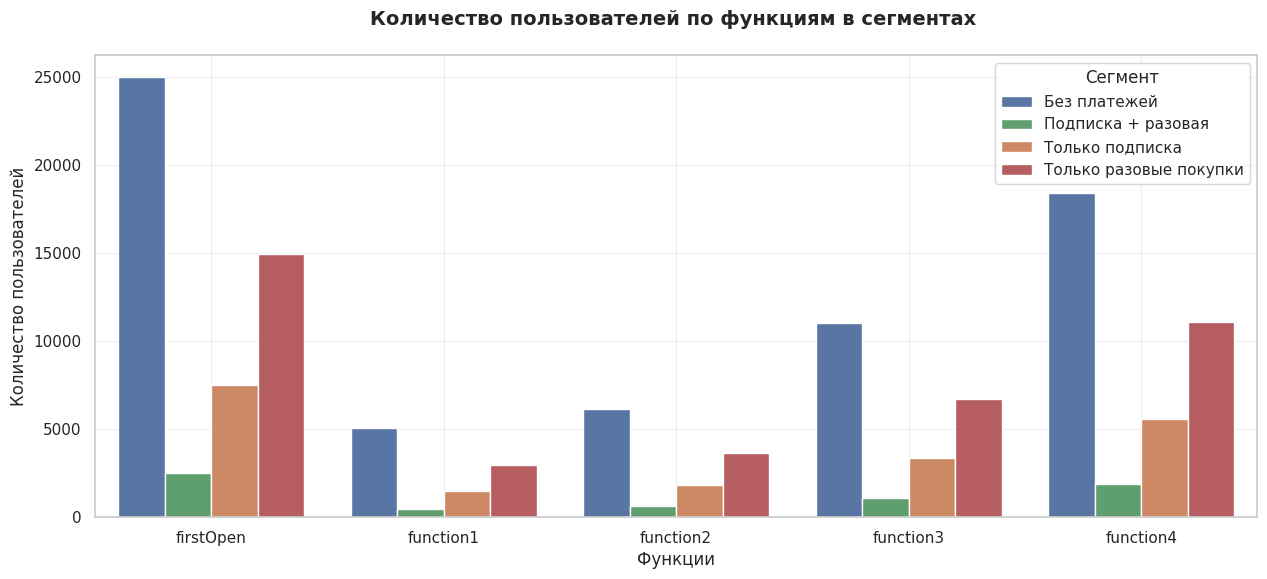

In [ ]:

sns.barplot(
    data=df_grouped.reset_index(),
    x='Action',
    y='count_user',
    hue='segment_name',
    palette=PALETTE_SEGMENTS
)

plt.title('Количество пользователей по функциям в сегментах \n')
plt.ylabel('Количество пользователей')
plt.xlabel('Функции')
plt.grid(True, alpha=0.3)
plt.legend(title='Сегмент')
plt.show()


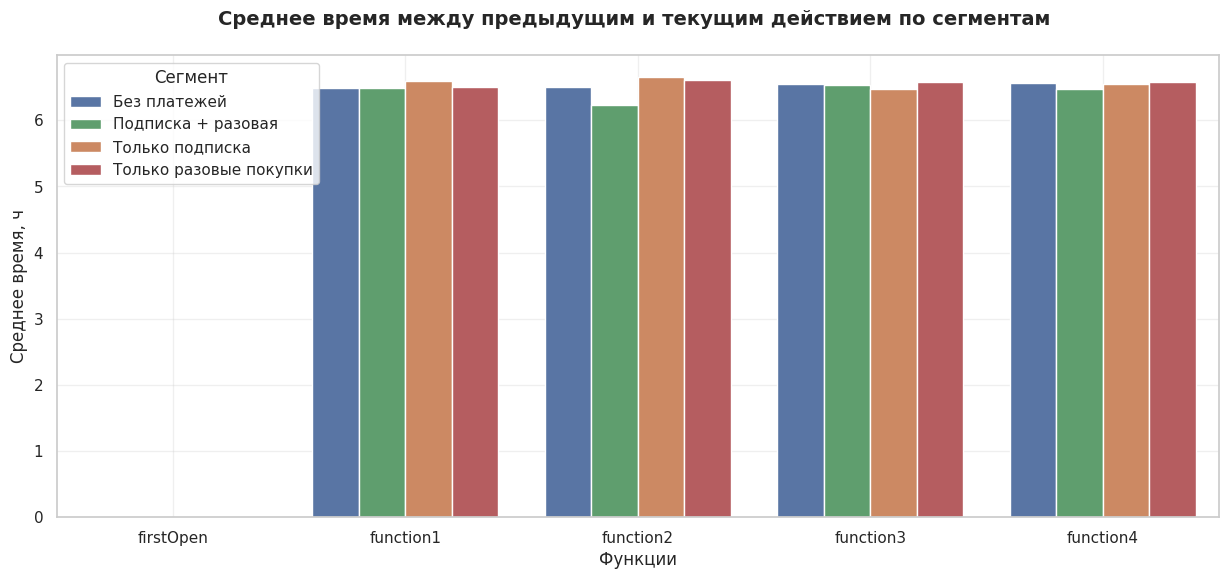

In [ ]:

sns.barplot(
    data=df_grouped.reset_index(),
    x='Action',
    y='avg_delta_prev_hours',
    hue='segment_name',
    palette=PALETTE_SEGMENTS
)

plt.title('Среднее время между предыдущим и текущим действием по сегментам \n')
plt.ylabel('Среднее время, ч')
plt.xlabel('Функции')
plt.grid(True, alpha=0.3)
plt.legend(title='Сегмент')
plt.show()


In [ ]:
df_pay_hist.head()

,uid,paymentType,Payment,segment_name
0,pkyhd,type1,400,Подписка + разовая
1,auben,type1,400,Только подписка
2,ahcar,type2,200,Только разовые покупки
3,ummyb,type2,200,Только разовые покупки
4,lprbt,type2,200,Подписка + разовая


In [ ]:
# Всего пользователей
all_users = df['uid'].nunique() #50000

# Платящие пользователи
paying_users = df_pay_user.uid.nunique() #25000

# Общая выручка
total_revenue = df_pay_user['Payment'].sum() #7516200

# Количество платежей
total_payments = df_pay_hist.Payment.count() #27532

# Средний чек на транзакцию
aov = total_revenue / total_payments

# Средний доход на платящего пользователя
arppu = total_revenue / paying_users

# Средний доход на всех пользователей
arpu = total_revenue / all_users

print(f"AOV: {aov:.2f}")
print(f"ARPPU: {arppu:.2f}")
print(f"ARPU: {arpu:.2f}")


AOV: 273.00
ARPPU: 300.65
ARPU: 150.32


1. Общие метрики

AOV: 273.00
ARPPU: 300.65
ARPU: 150.32

Разница между ARPU и ARPPU составляет примерно 50%, что отражает, что значительная часть пользователей не платит.

Таким образом, монетизация среди платящих пользователей работает эффективно, а ключевое ограничение роста выручки находится в конверсии пользователей в оплату.

2. Ключевой поведенческий результат

Несмотря на различия в типах платежей, пользователи всех сегментов демонстрируют практически идентичное поведение:

2.1. Доля пользователей, доходящих до ключевых функций, сопоставима между сегментами:

* пользователи без платежей доходят до тех же функций,

* платежные сегменты пользователей не демонстрируют значимой разницы по охвату функциональности.

2.2. Среднее время между действиями сопоставима между сегментами:

* скорость освоения продукта одинакова,

* различия использования приложения между сегментами отсутствуют.

Таким образом, конверсия в оплату не связана с доступностью функций или глубиной использования продукта. Продукт успешно вовлекает пользователей, а проблема монетизации лежит в модели извлечения ценности, а не в пользовательском опыте.

При этом факт наличия оплат у части аудитории, несмотря на одинаковое поведение, вероятно, связан не с доступом к функциональности, а с дополнительными факторами монетизации — например, рекламой, всплывающими ограничениями или другими элементами бесплатной версии. В таком случае пользователи оформляют разовую покупку или подписку, чтобы убрать раздражающие факторы и повысить комфорт использования.

# Общий вывод

Анализ исторических данных показал, что продукт успешно решает задачу вовлечения пользователей, но имеет значительный потенциал роста монетизации.

Поведенческий анализ показал, что платящие и неплатящие пользователи доходят до одних и тех же функций, используют продукт с сопоставимой скоростью и не отличаются по глубине использования, при этом подписка приносит большую выручку на пользователя, но её охват остаётся ограниченным.

Таким образом, пользователи без платежей получают практически ту же продуктовую ценность, что и платящие. Это указывает на две ключевые причины текущих ограничений монетизации: с одной стороны, у пользователей отсутствует достаточная мотивация платить, поскольку значимая часть ценности доступна бесплатно; с другой — цена подписки может выступать барьером входа, из-за чего часть аудитории предпочитает разовые платежи вместо регулярной модели.

Наибольший потенциал роста выручки находится в двух направлениях:

1. оптимизация цены подписки, поскольку её текущий уровень может ограничивать конверсию;

2. пересмотр логики доступа к функциям между бесплатной и платной версиями, так как в существующей модели большинством функций пользуются как платящие, так и бесплатные пользователи, что снижает воспринимаемую ценность оплаты.

# 4. АА-тест

In [ ]:
df.head()

,uid,Ts,Action,open_ts,delta_ts,delta_hours,prev_ts,delta_prev_ts,delta_prev_hours,Payment,segment_name
0,aaaaw,2019-11-26 21:48:12.053588,firstOpen,2019-11-26 21:48:12.053588,0 days 00:00:00,0.00,NaT,NaT,NaN,200.0,Только разовые покупки
1,aaaaw,2019-11-27 08:03:10.759203,function1,2019-11-26 21:48:12.053588,0 days 10:14:58.705615,10.25,2019-11-26 21:48:12.053588,0 days 10:14:58.705615,10.249640,200.0,Только разовые покупки
2,aaacj,2019-11-29 16:14:23.163530,firstOpen,2019-11-29 16:14:23.163530,0 days 00:00:00,0.00,NaT,NaT,NaN,400.0,Только подписка
3,aaacj,2019-11-30 02:12:40.876643,function3,2019-11-29 16:14:23.163530,0 days 09:58:17.713113,9.97,2019-11-29 16:14:23.163530,0 days 09:58:17.713113,9.971587,400.0,Только подписка
4,aaacj,2019-11-30 03:01:45.242326,function4,2019-11-29 16:14:23.163530,0 days 10:47:22.078796,10.79,2019-11-30 02:12:40.876643,0 days 00:49:04.365683,0.817879,400.0,Только подписка


In [ ]:
df.shape

(131449, 11)

In [ ]:
# 1. Агрегируем данные по пользователям до разбиения на группы

df_user = df.groupby('uid', as_index=False)\
            .agg(events_count=('Action','count'),
                 avg_delta_hours=('delta_hours','mean'),
                 has_sub=('segment_name', lambda x: any(x.isin(['Только подписка','Подписка + разовая']))))

df_user['has_sub'] = df_user['has_sub'].astype(int)

df_user.head()

,uid,events_count,avg_delta_hours,has_sub
0,aaaaw,2,5.125000,0
1,aaacj,3,6.920000,1
2,aaahu,2,4.605000,0
3,aacpg,2,4.535000,0
4,aaczh,3,9.443333,0


In [ ]:
df_user.shape

(50000, 4)

In [ ]:
# 2. Создаём случайное AA-разбиение

np.random.seed(42)
df_user['group'] = np.random.choice(['T','C'], size=len(df_user))

df_user.head()

,uid,events_count,avg_delta_hours,has_sub,group
0,aaaaw,2,5.125000,0,T
1,aaacj,3,6.920000,1,C
2,aaahu,2,4.605000,0,T
3,aacpg,2,4.535000,0,T
4,aaczh,3,9.443333,0,T


In [ ]:
df_user['group'].value_counts()


,count
group,
T,25046
C,24954


In [ ]:
# 3. Проверка сбалансированности групп

metrics = ['has_sub','events_count','avg_delta_hours']

print("Средние значения по группам:")
print(df_user.groupby('group')[metrics].mean())

print("\nСтандартное отклонение по группам:")
print(df_user.groupby('group')[metrics].std())


Средние значения по группам:
        has_sub  events_count  avg_delta_hours
group                                         
C      0.197884      2.625551         5.309629
T      0.204065      2.632396         5.358479

Стандартное отклонение по группам:
        has_sub  events_count  avg_delta_hours
group                                         
C      0.398412      0.652845          3.70349
T      0.403024      0.656265          3.70539


Средние значения и стандартные отклонения почти идентичны между группами Т и C, следовательно группы балансированы.

In [ ]:
# 4. Статистические тесты на равенство средних

In [ ]:
group_T = df_user[df_user['group'] == 'T']
group_C = df_user[df_user['group'] == 'C']

In [ ]:
contingency = np.array([
    [group_T['has_sub'].sum(), len(group_T) - group_T['has_sub'].sum()],
    [group_C['has_sub'].sum(), len(group_C) - group_C['has_sub'].sum()]
])

chi2, p_has_sub, _, _ = chi2_contingency(contingency)

print(f"has_sub: chi2 p-value = {p_has_sub:.4f}")


has_sub: chi2 p-value = 0.0867


In [ ]:
t_stat_events, p_events = ttest_ind(
    group_T['events_count'],
    group_C['events_count'],
    equal_var=False
)

print(f"events_count: t-test p-value = {p_events:.4f}")


events_count: t-test p-value = 0.2423


In [ ]:
t_stat_time, p_time = ttest_ind(
    group_T['avg_delta_hours'],
    group_C['avg_delta_hours'],
    equal_var=False
)

print(f"avg_delta_hours: t-test p-value = {p_time:.4f}")

avg_delta_hours: t-test p-value = 0.1404


p-value > 0.05 → статистически значимых различий между группами нет.

In [ ]:
#  Считаем MDE на AA-тесте

alpha = 0.05
beta = 0.2

aa_test = group_T['has_sub'].values
aa_control = group_C['has_sub'].values

MDE_absolute = (
    sps.norm.ppf(1 - alpha) + sps.norm.ppf(1 - beta)
) * np.sqrt(
    np.var(aa_test, ddof=1) / len(aa_test) +
    np.var(aa_control, ddof=1) / len(aa_control)
)

MDE_rel = MDE_absolute / np.mean(aa_control)

print(f"Абсолютный MDE: {MDE_absolute:.4f}")
print(f"Относительный MDE: {MDE_rel*100:.1f}%")

Абсолютный MDE: 0.0089
Относительный MDE: 4.5%



Это означает, что при текущем размере выборки и параметрах теста (α = 0.05, power = 80%) эксперимент способен статистически значимо обнаружить изменения метрики не менее чем на 4.5% относительно базового уровня.

Эффекты меньшего размера могут присутствовать, однако данный тест не обладает достаточной чувствительностью для их надежного выявления.

- Если реальное изменение ≥ 4.5% → тест с высокой вероятностью его обнаружит.

- Если изменение < 4.5% → тест может показать отсутствие статистической значимости, даже если эффект существует.



In [ ]:
# Расчет размера выборки

p = 0.2009            # текущая доля подписчиков
MDE = 0.0089

# Квантили нормального распределения для одностороннего теста
z_alpha = sps.norm.ppf(1 - alpha)
z_beta = sps.norm.ppf(1 - beta)

# Размер выборки для каждой группы
n = ((z_alpha + z_beta)**2 * (p*(1-p) + (p+MDE)*(1-(p+MDE)))) / MDE**2
n = np.ceil(n)

print(f"Необходимая выборка в каждой группе: {n:.0f} пользователей")


Необходимая выборка в каждой группе: 25471 пользователей


In [ ]:

# Расчет продолжительности теста

# 1. Считаем общее число дней
min_date = df['Ts'].min().normalize()
max_date = df['Ts'].max().normalize()
num_days = (max_date - min_date).days + 1  # +1 чтобы включить последний день

total_users = df['uid'].nunique()

avg_users_per_day = total_users / num_days
print(f"Среднее число уникальных пользователей в день: {round(avg_users_per_day)}")

avg_users_per_group_per_day = avg_users_per_day / 2
print(f"Число пользователей на группу в день: {round(avg_users_per_group_per_day)}")

required_sample_per_group = n

required_days = required_sample_per_group / avg_users_per_group_per_day
print(f"Необходимая продолжительность теста: {required_days:.1f} дней")


Среднее число уникальных пользователей в день: 4167
Число пользователей на группу в день: 2083
Необходимая продолжительность теста: 12.2 дней


In [ ]:
# Симуляция АА-теста

np.random.seed(42)

metrics = ['has_sub', 'events_count', 'avg_delta_hours']
n_simulations = 1000
aa_results = {}

n = df_user.shape[0]

for metric in metrics:
    false_positives = 0
    values = df_user[metric].values

    for _ in range(n_simulations):
        idx = np.random.permutation(n)
        group1 = values[idx[:n//2]]
        group2 = values[idx[n//2:]]

        if metric == 'has_sub':
            contingency = np.array([
                [group1.sum(), len(group1)-group1.sum()],
                [group2.sum(), len(group2)-group2.sum()]
            ])
            chi2, p, _, _ = chi2_contingency(contingency)
        else:
            _, p = ttest_ind(group1, group2, equal_var=False)

        if p < 0.05:
            false_positives += 1

    aa_results[metric] = false_positives / n_simulations

# Вывод
for m, fp in aa_results.items():
    print(f"{m}: доля ложных срабатываний на A/A = {fp:.3f}")


has_sub: доля ложных срабатываний на A/A = 0.058
events_count: доля ложных срабатываний на A/A = 0.041
avg_delta_hours: доля ложных срабатываний на A/A = 0.055


AA-тест показал, что группы пользователей сбалансированы: ложные срабатывания близки к 5%, статистически значимых различий нет. Разбиение корректно, можно доверять будущему AB-тесту.

# 5. Анализ итогов эксперимента

## 5.1. Предобработка данных

In [ ]:
df_act_exp = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/АБ дизайн/Action.csv')

In [ ]:
df_act_exp.head()

,uid,Ts,Action
0,cfjqq,2020-01-16 09:24:32,firstOpen
1,cfjqq,2020-01-16 15:39:41,function2
2,cfjqq,2020-01-16 15:58:21,function4
3,hclau,2020-01-10 22:54:42,firstOpen
4,hclau,2020-01-11 01:19:03,function1


Action = firstOpen – событие первого входа пользователя в продукт.

Action = functionX – факты взаимодействия пользователя с фичами продукта, где X – id конкретной фичи.


In [ ]:
df_act_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185189 entries, 0 to 185188
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   uid     185189 non-null  object
 1   Ts      185189 non-null  object
 2   Action  185189 non-null  object
dtypes: object(3)
memory usage: 4.2+ MB


In [ ]:
df_act_exp['Ts'] = pd.to_datetime(df_act_exp['Ts'])

In [ ]:
df_act_exp.describe()

,Ts
count,185189
mean,2020-01-15 03:48:44.954856960
min,2020-01-09 19:00:27
25%,2020-01-12 16:11:15
50%,2020-01-15 03:57:31
75%,2020-01-17 15:41:45
max,2020-01-20 18:50:42


In [ ]:
df_act_exp.isna().sum()

,0
uid,0
Ts,0
Action,0


In [ ]:
df_act_exp.duplicated().sum()

np.int64(0)

In [ ]:
df_act_exp['Action'].unique()

array(['firstOpen', 'function2', 'function4', 'function1', 'function3'],
      dtype=object)

In [ ]:
df_act_exp = df_act_exp.sort_values(by=['uid', 'Ts'])

In [ ]:
# Количество уникальных пользователей

df_act_exp.uid.nunique()


50001

In [ ]:
# Количество новых пользователей

df_act_exp.query('Action == "firstOpen"').uid.nunique()

50001

In [ ]:
# Расчёт распределения времени от первого входа до пользовательских действий

df_act_exp['open_ts'] = df_act_exp.groupby('uid', as_index=False)['Ts'].transform('min')

df_act_exp['delta_ts'] = df_act_exp['Ts'] - df_act_exp['open_ts']

df_act_exp['delta_hours'] =  (df_act_exp['delta_ts'].dt.total_seconds() / 3600).round(2)

df_act_exp.head()

,uid,Ts,Action,open_ts,delta_ts,delta_hours
110148,aaago,2020-01-16 22:01:51,firstOpen,2020-01-16 22:01:51,0 days 00:00:00,0.00
110149,aaago,2020-01-17 13:24:32,function1,2020-01-16 22:01:51,0 days 15:22:41,15.38
110150,aaago,2020-01-17 13:38:16,function4,2020-01-16 22:01:51,0 days 15:36:25,15.61
75445,aaahw,2020-01-19 12:29:40,firstOpen,2020-01-19 12:29:40,0 days 00:00:00,0.00
75446,aaahw,2020-01-19 21:14:46,function2,2020-01-19 12:29:40,0 days 08:45:06,8.75


In [ ]:
# Анализ времени между последовательными действиями пользователя

df_act_exp['prev_ts'] = df_act_exp.groupby('uid', as_index=False)['Ts'].shift(1)

df_act_exp['delta_prev_ts'] = df_act_exp['Ts'] - df_act_exp['prev_ts']

df_act_exp['delta_prev_hours'] =  df_act_exp['delta_prev_ts'].dt.total_seconds() / 3600


In [ ]:
df_act_exp.head()

,uid,Ts,Action,open_ts,delta_ts,delta_hours,prev_ts,delta_prev_ts,delta_prev_hours
110148,aaago,2020-01-16 22:01:51,firstOpen,2020-01-16 22:01:51,0 days 00:00:00,0.00,NaT,NaT,NaN
110149,aaago,2020-01-17 13:24:32,function1,2020-01-16 22:01:51,0 days 15:22:41,15.38,2020-01-16 22:01:51,0 days 15:22:41,15.378056
110150,aaago,2020-01-17 13:38:16,function4,2020-01-16 22:01:51,0 days 15:36:25,15.61,2020-01-17 13:24:32,0 days 00:13:44,0.228889
75445,aaahw,2020-01-19 12:29:40,firstOpen,2020-01-19 12:29:40,0 days 00:00:00,0.00,NaT,NaT,NaN
75446,aaahw,2020-01-19 21:14:46,function2,2020-01-19 12:29:40,0 days 08:45:06,8.75,2020-01-19 12:29:40,0 days 08:45:06,8.751667


In [ ]:
df_pay_exp = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/АБ дизайн/Payment.csv')

In [ ]:
df_pay_exp.head()

,uid,paymentType,Payment
0,hclau,type1,400
1,hclau,type2,200
2,bkhtq,type2,200
3,rxxdh,type2,200
4,qxjhx,type1,400


paymentType = type1 – покупка подписки. Может быть 160 или 400.

paymentType = type2 – разовая покупка. Всегда 200.



In [ ]:
df_pay_exp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36058 entries, 0 to 36057
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   uid          36058 non-null  object
 1   paymentType  36058 non-null  object
 2   Payment      36058 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 845.2+ KB


In [ ]:
df_pay_exp.isna().sum()

,0
uid,0
paymentType,0
Payment,0


In [ ]:
df_pay_exp.paymentType.unique()

array(['type1', 'type2'], dtype=object)

In [ ]:
# количество платящих пользователей

df_pay_exp.uid.nunique()


29530

In [ ]:
df_pay_exp_pivot = df_pay_exp.pivot_table(index='uid',
                                            columns='paymentType',
                                            values='Payment',
                                            aggfunc='count',
                                            fill_value=0).reset_index()

df_pay_exp_pivot.head()

paymentType,uid,type1,type2
0,aaago,1,0
1,aaaii,1,1
2,aabfn,1,0
3,aabhx,0,1
4,aabka,0,1


In [ ]:
# Найдем уникальное сочетание типов платежей

df_pay_exp_pivot[['type1','type2']].drop_duplicates()


paymentType,type1,type2
0,1,0
1,1,1
3,0,1


In [ ]:
# добавим столбец с указанием сегмента плательщика

df_pay_exp_pivot['segment_code'] = (
    df_pay_exp_pivot['type1'].gt(0).astype(int).astype(str)
    + '_'
    + df_pay_exp_pivot['type2'].gt(0).astype(int).astype(str)
)

df_pay_exp_pivot['segment_name'] = df_pay_exp_pivot['segment_code'].map({
    '1_0': 'Только подписка',
    '0_1': 'Только разовые покупки',
    '1_1': 'Подписка + разовая'

})

df_pay_exp_pivot.head()

paymentType,uid,type1,type2,segment_code,segment_name
0,aaago,1,0,1_0,Только подписка
1,aaaii,1,1,1_1,Подписка + разовая
2,aabfn,1,0,1_0,Только подписка
3,aabhx,0,1,0_1,Только разовые покупки
4,aabka,0,1,0_1,Только разовые покупки


In [ ]:
df_pay_exp = df_pay_exp.merge(df_pay_exp_pivot[['uid', 'segment_name']], on='uid', how='left')

df_pay_exp.head()


,uid,paymentType,Payment,segment_name
0,hclau,type1,400,Подписка + разовая
1,hclau,type2,200,Подписка + разовая
2,bkhtq,type2,200,Только разовые покупки
3,rxxdh,type2,200,Только разовые покупки
4,qxjhx,type1,400,Подписка + разовая


In [ ]:
df_group = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/АБ дизайн/Experiments.csv')

In [ ]:
df_group.head()

,Experiment,Group,uid
0,actionChange,Old,cfjqq
1,actionChange,Old,hclau
2,actionChange,Old,bkhtq
3,actionChange,Old,rxxdh
4,actionChange,Old,ccsko


Experiment = paymentChange – эксперимент на изменение цены

Experiment = actionChange – какой-то другой эксперимент

Group = Old – контрольная группа

Group = New – тестовая группа




In [ ]:
df_group.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100002 entries, 0 to 100001
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Experiment  100002 non-null  object
 1   Group       100002 non-null  object
 2   uid         100002 non-null  object
dtypes: object(3)
memory usage: 2.3+ MB


In [ ]:
df_group.nunique()

,0
Experiment,2
Group,2
uid,50001


In [ ]:
df_group.Experiment.unique()

array(['actionChange', 'paymentChange'], dtype=object)

In [ ]:
df_group_payment = df_group.query('Experiment == "paymentChange"')


## 5.2. Метрики эксперимента

### Активность

In [ ]:
df_act_exp = df_act_exp.merge(df_group_payment[['uid', 'Group']], on='uid', how='left')

df_act_exp.head()

,uid,Ts,Action,open_ts,delta_ts,delta_hours,prev_ts,delta_prev_ts,delta_prev_hours,Group
0,aaago,2020-01-16 22:01:51,firstOpen,2020-01-16 22:01:51,0 days 00:00:00,0.00,NaT,NaT,NaN,Old
1,aaago,2020-01-17 13:24:32,function1,2020-01-16 22:01:51,0 days 15:22:41,15.38,2020-01-16 22:01:51,0 days 15:22:41,15.378056,Old
2,aaago,2020-01-17 13:38:16,function4,2020-01-16 22:01:51,0 days 15:36:25,15.61,2020-01-17 13:24:32,0 days 00:13:44,0.228889,Old
3,aaahw,2020-01-19 12:29:40,firstOpen,2020-01-19 12:29:40,0 days 00:00:00,0.00,NaT,NaT,NaN,New
4,aaahw,2020-01-19 21:14:46,function2,2020-01-19 12:29:40,0 days 08:45:06,8.75,2020-01-19 12:29:40,0 days 08:45:06,8.751667,New


In [ ]:
df_act_exp.shape

(185189, 10)

In [ ]:
df_user_exp = df_act_exp.groupby('uid', as_index=False)\
                        .agg(events_count=('Action', 'count'),
                            avg_delta_hours=('delta_hours', 'mean'),
                            avg_delta_prev_hours=('delta_prev_hours', 'mean'),
                            Group=('Group', 'first'))

df_user_exp.head()

,uid,events_count,avg_delta_hours,avg_delta_prev_hours,Group
0,aaago,3,10.330000,7.803472,Old
1,aaahw,4,10.365000,6.226481,New
2,aaaii,3,15.146667,11.519583,New
3,aaaim,4,6.760000,4.473519,New
4,aaaop,4,9.942500,6.520463,Old


In [ ]:
df_user_exp.shape

(50001, 5)

In [ ]:
#events_count → среднее число действий на пользователя

#avg_delta_hours → среднее время до действий на пользователя

#avg_delta_prev_hours → средний интервал между действиями на пользователя

df_user_exp.groupby('Group', as_index=False)\
           .agg(events_count=('events_count', 'mean'),
                avg_delta_hours=('avg_delta_hours', 'mean'),
                avg_delta_prev_hours=('avg_delta_prev_hours', 'mean'))


,Group,events_count,avg_delta_hours,avg_delta_prev_hours
0,New,3.702000,8.616435,6.708049
1,Old,3.705412,8.648942,6.710221


In [ ]:

control = df_user_exp[df_user_exp['Group'] == 'Old']
test = df_user_exp[df_user_exp['Group'] == 'New']


In [ ]:
# Проверка стат. значимости (ttest):

#events_count → среднее число действий на пользователя

#avg_delta_hours → среднее время до действий на пользователя

#avg_delta_prev_hours → средний интервал между действиями на пользователя


metrics = ['events_count', 'avg_delta_hours', 'avg_delta_prev_hours']

p_values = []
results = []

# 1. Считаем t-test и сохраняем данные
for metric in metrics:
    stat, pvalue = ttest_ind(
        test[metric],
        control[metric],
        equal_var=False,
        nan_policy='omit'
    )

    diff = test[metric].mean() - control[metric].mean()
    diff_pct = diff / control[metric].mean() * 100

    p_values.append(pvalue)
    results.append({
        'metric': metric,
        'control_mean': control[metric].mean(),
        'test_mean': test[metric].mean(),
        'diff_abs': diff,
        'diff_pct': diff_pct
    })

# 2. FDR-коррекция
rejected, pvals_corrected, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method='fdr_bh'
)

# 3. Вывод только скорректированных результатов
for i, res in enumerate(results):
    print(f"\nМетрика: {res['metric']}")
    print(f"Среднее Control: {res['control_mean']:.3f}")
    print(f"Среднее Test: {res['test_mean']:.3f}")
    print(f"Абс. разница: {res['diff_abs']:.3f}")
    print(f"Отн. разница: {res['diff_pct']:.2f}%")
    print(f"p-value: {pvals_corrected[i]:.4f}")
    print(f"Значимо: {rejected[i]}")



Метрика: events_count
Среднее Control: 3.705
Среднее Test: 3.702
Абс. разница: -0.003
Отн. разница: -0.09%
p-value: 0.8261
Значимо: False

Метрика: avg_delta_hours
Среднее Control: 8.649
Среднее Test: 8.616
Абс. разница: -0.033
Отн. разница: -0.38%
p-value: 0.7554
Значимо: False

Метрика: avg_delta_prev_hours
Среднее Control: 6.710
Среднее Test: 6.708
Абс. разница: -0.002
Отн. разница: -0.03%
p-value: 0.9300
Значимо: False


Анализ поведенческих метрик не выявил статистически значимых различий между контрольной и тестовой группами (p-value > 0.05 для всех метрик).
Это свидетельствует о том, что изменение цены не повлияло на пользовательскую активность и вовлеченность.

### Платежность (только платящие)

In [ ]:
df_pay_exp = df_pay_exp.merge(df_group_payment[['uid', 'Group']], on='uid', how='left')

In [ ]:
df_pay_exp.head()

,uid,paymentType,Payment,segment_name,Group
0,hclau,type1,400,Подписка + разовая,Old
1,hclau,type2,200,Подписка + разовая,Old
2,bkhtq,type2,200,Только разовые покупки,Old
3,rxxdh,type2,200,Только разовые покупки,Old
4,qxjhx,type1,400,Подписка + разовая,Old


In [ ]:
df_pay_exp.shape

(36058, 5)

In [ ]:
# Расчет ключевых метрик платежности: число платящих,
#                                     суммарный доход,
#                                     средний чек,
#                                     средний доход на платящего (ARPPU)

payment_metrics = df_pay_exp.groupby('Group', as_index=False)\
                            .agg(total_payers = ('uid', 'nunique'),
                                total_revenue = ('Payment', 'sum'),
                                aov = ('Payment', 'mean'))

payment_metrics['ARPPU'] = payment_metrics['total_revenue'] / payment_metrics['total_payers']

payment_metrics

,Group,total_payers,total_revenue,aov,ARPPU
0,New,17119,3860640,177.117952,225.517846
1,Old,12411,3845800,269.672533,309.870276


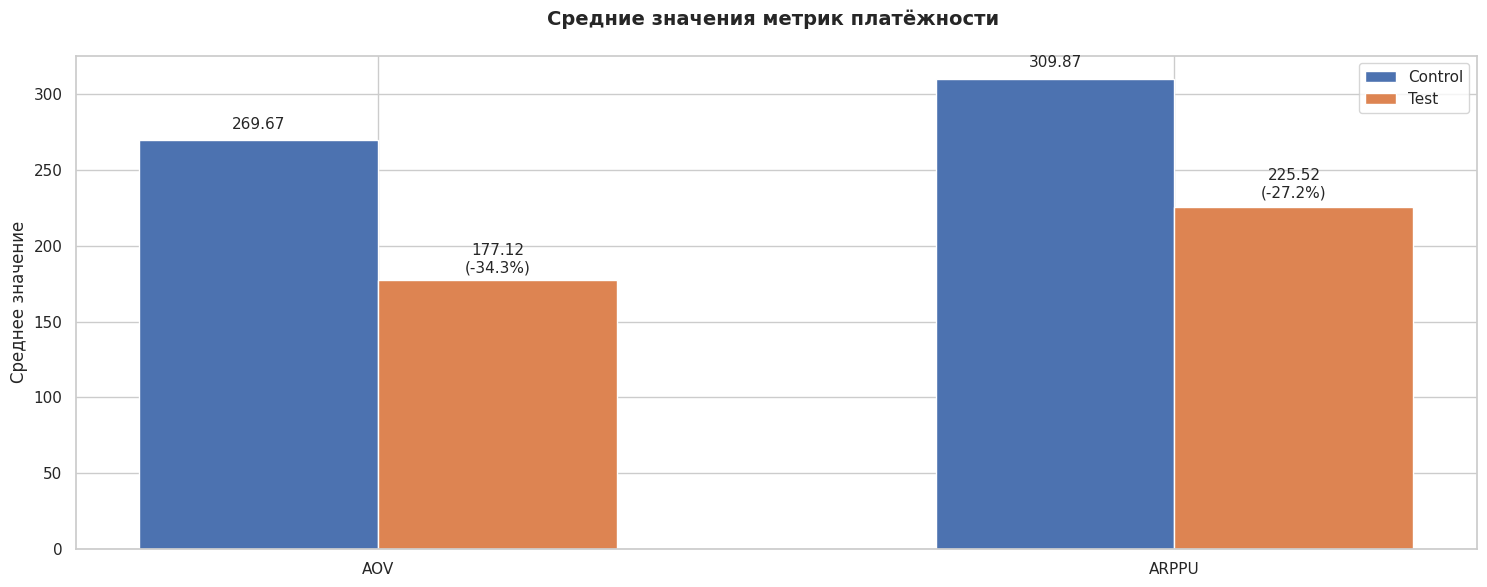

In [ ]:
# Средние значения метрик платёжности

df_plot = payment_metrics[['Group','aov','ARPPU']].copy()
metrics = ['aov','ARPPU']
x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots()

control_vals = df_plot[df_plot['Group']=='Old'][metrics].values.flatten()
test_vals = df_plot[df_plot['Group']=='New'][metrics].values.flatten()

ax.bar(x - width/2, control_vals, width, label='Control', color=PALETTE["control"])
ax.bar(x + width/2, test_vals, width, label='Test', color=PALETTE["test"])

for i in range(len(metrics)):
    diff_pct = (test_vals[i] - control_vals[i]) / control_vals[i] * 100
    ax.text(i - width/2, control_vals[i] + 0.02*control_vals[i], f'{control_vals[i]:.2f}', ha='center', va='bottom')
    ax.text(i + width/2, test_vals[i] + 0.02*test_vals[i], f'{test_vals[i]:.2f}\n({diff_pct:+.1f}%)', ha='center', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(['AOV','ARPPU'])
ax.set_ylabel('Среднее значение')
ax.set_title('Средние значения метрик платёжности \n')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
df_user_pay = df_pay_exp.groupby(['uid','Group'], as_index=False)\
                        .agg(revenue=('Payment','sum'),
                             payments=('Payment','count'),
                             aov=('Payment','mean'))

df_user_pay.head()


,uid,Group,revenue,payments,aov
0,aaago,Old,400,1,400.0
1,aaaii,New,360,2,180.0
2,aabfn,New,160,1,160.0
3,aabhx,Old,200,1,200.0
4,aabka,New,200,1,200.0


In [ ]:
df_user_pay.shape

(29530, 5)

In [ ]:
# Проверка стат значимости ARPPU (t-test )

control_arppu = df_user_pay[df_user_pay['Group']=='Old'].copy()
test_arppu = df_user_pay[df_user_pay['Group']=='New'].copy()

stat, pvalue = ttest_ind(test_arppu['revenue'], control_arppu['revenue'], equal_var=False)
diff = test_arppu['revenue'].mean() - control_arppu['revenue'].mean()
diff_pct = diff / control_arppu['revenue'].mean() * 100

cm = sm.stats.CompareMeans(
    sm.stats.DescrStatsW(test_arppu['revenue']),
    sm.stats.DescrStatsW(control_arppu['revenue'])
)
ci_low, ci_up = cm.tconfint_diff(alpha=0.05)

print("ARPPU:")
print(f"Control mean: {control_arppu['revenue'].mean():.2f}")
print(f"Test mean: {test_arppu['revenue'].mean():.2f}")
print(f"Абсолютная разница: {diff:.2f}")
print(f"Относительная разница: {diff_pct:.2f}%")
print(f"95% CI: ({ci_low:.2f}, {ci_up:.2f})")
print(f"p-value: {pvalue:.4f}\n")

ARPPU:
Control mean: 309.87
Test mean: 225.52
Абсолютная разница: -84.35
Относительная разница: -27.22%
95% CI: (-87.01, -81.69)
p-value: 0.0000



In [ ]:
# Проверка стат значимости AOV (Bootstrap)

control = df_user_pay[df_user_pay['Group']=='Old']['aov'].dropna().values
test = df_user_pay[df_user_pay['Group']=='New']['aov'].dropna().values

n_boot = 10000
rng = np.random.default_rng(seed=42)

def bootstrap_diff(control, test, n_boot=10000):
    diffs = []
    for _ in range(n_boot):
        ctrl_sample = rng.choice(control, size=len(control), replace=True)
        test_sample = rng.choice(test, size=len(test), replace=True)
        diffs.append(test_sample.mean() - ctrl_sample.mean())
    return np.array(diffs)

diffs = bootstrap_diff(control, test, n_boot=n_boot)

diff_mean = diffs.mean()
diff_pct = diff_mean / control.mean() * 100
ci_lower, ci_upper = np.percentile(diffs, [2.5, 97.5])

p_value = 2 * min(np.mean(diffs <= 0), np.mean(diffs > 0))

print("AOV:")
print(f"Control mean: {control.mean():.2f}")
print(f"Test mean: {test.mean():.2f}")
print(f"Абсолютная разница: {diff_mean:.2f}")
print(f"Относительная разница: {diff_pct:.2f}%")
print(f"95% CI: ({ci_lower:.2f}, {ci_upper:.2f})")
print(f"p-value: {p_value:.4f}")

AOV:
Control mean: 265.15
Test mean: 176.33
Абсолютная разница: -88.81
Относительная разница: -33.49%
95% CI: (-90.33, -87.24)
p-value: 0.0000


Вывод по платежности (платящие пользователи):

Тестовая группа  привлекла больше платящих пользователей на 38%, но каждый платящий тратил меньше. В результате общая выручка осталась примерно на том же уровне.

Средний чек снизился на 34%, а доход на платящего -  на 27%. Изменения статистически значимы.

Эксперимент увеличил количество платящих пользователей, но снизил доход с каждого пользователя, что  что нивелировало общий эффект на выручку.


###  Анализ по сегментам и платежности между группами

In [ ]:
# Агрегируем платежные данные на пользователя

df_user_pay = df_pay_exp.groupby(['uid'], as_index=False).agg(
    total_revenue=('Payment','sum'),
    payments_count=('Payment','count'),
    aov=('Payment','mean'),
    segment_name=('segment_name','first'))


In [ ]:
df = df_act_exp.merge(df_user_pay, on='uid', how='left')

df['segment_name'] = df['segment_name'].fillna('Без платежей')

df.head()

,uid,Ts,Action,open_ts,delta_ts,delta_hours,prev_ts,delta_prev_ts,delta_prev_hours,Group,total_revenue,payments_count,aov,segment_name
0,aaago,2020-01-16 22:01:51,firstOpen,2020-01-16 22:01:51,0 days 00:00:00,0.00,NaT,NaT,NaN,Old,400.0,1.0,400.0,Только подписка
1,aaago,2020-01-17 13:24:32,function1,2020-01-16 22:01:51,0 days 15:22:41,15.38,2020-01-16 22:01:51,0 days 15:22:41,15.378056,Old,400.0,1.0,400.0,Только подписка
2,aaago,2020-01-17 13:38:16,function4,2020-01-16 22:01:51,0 days 15:36:25,15.61,2020-01-17 13:24:32,0 days 00:13:44,0.228889,Old,400.0,1.0,400.0,Только подписка
3,aaahw,2020-01-19 12:29:40,firstOpen,2020-01-19 12:29:40,0 days 00:00:00,0.00,NaT,NaT,NaN,New,NaN,NaN,NaN,Без платежей
4,aaahw,2020-01-19 21:14:46,function2,2020-01-19 12:29:40,0 days 08:45:06,8.75,2020-01-19 12:29:40,0 days 08:45:06,8.751667,New,NaN,NaN,NaN,Без платежей


In [ ]:
df_act_exp.shape

(185189, 10)

In [ ]:
df.shape

(185189, 14)

In [ ]:
# Заменяем NaN на 0 для неплатящих

df['total_revenue'] = df['total_revenue'].fillna(0)
df['payments_count'] = df['payments_count'].fillna(0)
df['aov'] = df['aov'].fillna(0)
df['paying'] = (df['total_revenue'] > 0).astype(int)


In [ ]:
# Агрегируем активность и платежи на уровне пользователя

df_user = df.groupby(['uid','Group'], as_index=False).agg(
    total_revenue=('total_revenue','first'),
    payments_count=('payments_count','first'),
    aov=('aov','first'),
    segment_name=('segment_name','first'),
    paying=('paying', 'first'))


df_user.head()


,uid,Group,total_revenue,payments_count,aov,segment_name,paying
0,aaago,Old,400.0,1.0,400.0,Только подписка,1
1,aaahw,New,0.0,0.0,0.0,Без платежей,0
2,aaaii,New,360.0,2.0,180.0,Подписка + разовая,1
3,aaaim,New,0.0,0.0,0.0,Без платежей,0
4,aaaop,Old,0.0,0.0,0.0,Без платежей,0


In [ ]:
df_user.shape

(50001, 7)

#### Распределение пользователей по сегментам

In [ ]:
segment_dist = (df_user.groupby(['Group','segment_name'], as_index=False)\
                  .agg(users=('uid', 'nunique')))

segment_dist['percent'] = (segment_dist.groupby('Group')['users'].transform(lambda x: x / x.sum() * 100))

segment_pivot = (segment_dist.pivot(index='segment_name', columns='Group', values='percent') .reset_index())

segment_pivot['diff_pp'] = segment_pivot['New'] - segment_pivot['Old']

segment_pivot = segment_pivot.sort_values('diff_pp', ascending=False)

segment_pivot.columns.name = None

segment_pivot


,segment_name,New,Old,diff_pp
2,Только подписка,31.164,12.471501,18.692499
1,Подписка + разовая,18.712,7.399704,11.312296
3,Только разовые покупки,18.600,29.770809,-11.170809
0,Без платежей,31.524,50.357986,-18.833986


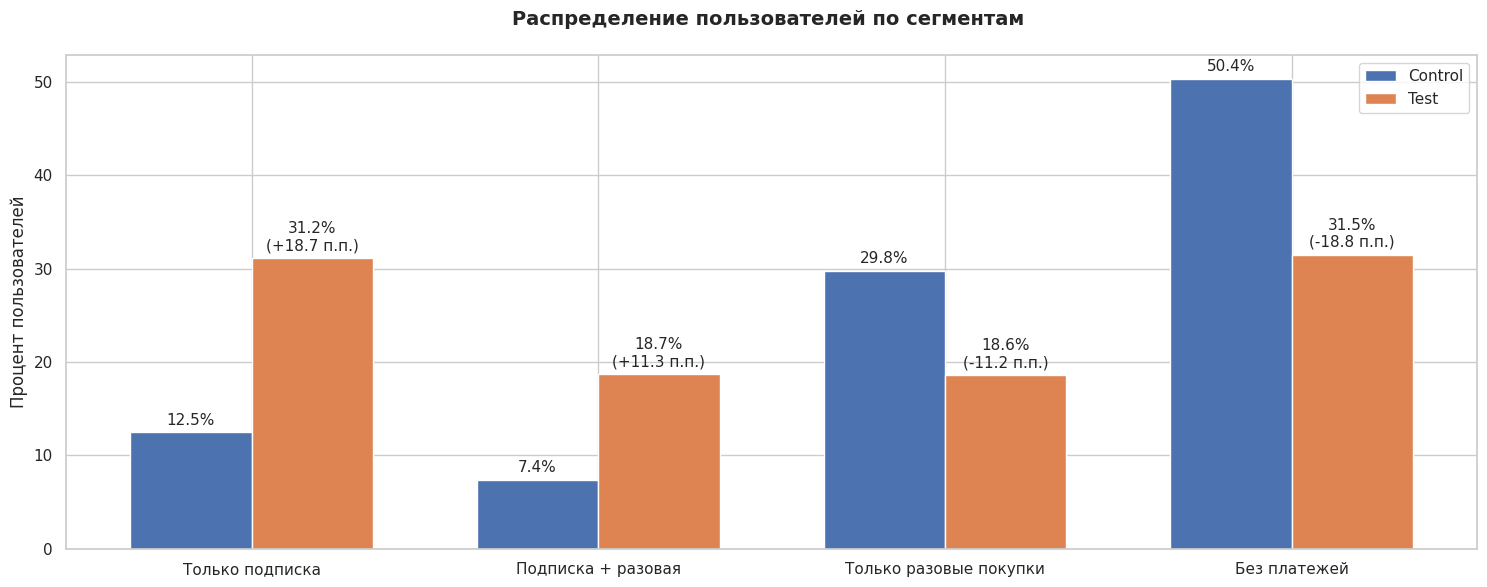

In [ ]:
# Распределение пользователей по сегментам

segments = segment_pivot['segment_name']
x = np.arange(len(segments))
width = 0.35

fig, ax = plt.subplots()

ax.bar(x - width/2, segment_pivot['Old'], width, label='Control', color=PALETTE["control"])
ax.bar(x + width/2, segment_pivot['New'], width, label='Test', color=PALETTE["test"])

ax.set_xticks(x)
ax.set_xticklabels(segments, )
ax.set_ylabel('Процент пользователей')
ax.set_title('Распределение пользователей по сегментам \n')
ax.legend()

for i in range(len(segments)):
    old_val = segment_pivot['Old'].iloc[i]
    new_val = segment_pivot['New'].iloc[i]
    diff_pp = new_val - old_val

    ax.text(i - width/2,
            old_val + 0.5,
            f'{old_val:.1f}%',
            ha='center', va='bottom')

    ax.text(i + width/2,
            new_val + 0.5,
            f'{new_val:.1f}%\n({diff_pp:+.1f} п.п.)',
            ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# Проверка стат значимости сегментов пользователей (хи-квадрат)

segments = df_user['segment_name'].unique()
results = []

control_total = df_user[df_user['Group']=='Old']['uid'].nunique()
test_total = df_user[df_user['Group']=='New']['uid'].nunique()

for seg in segments:

    control_in_seg = df_user[(df_user['Group']=='Old') & (df_user['segment_name']==seg)]['uid'].nunique()
    test_in_seg = df_user[(df_user['Group']=='New') & (df_user['segment_name']==seg)]['uid'].nunique()

    control_not_in_seg = control_total - control_in_seg
    test_not_in_seg = test_total - test_in_seg

    contingency_table = np.array([
        [test_in_seg, control_in_seg],
        [test_not_in_seg, control_not_in_seg]
    ])

    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    test_share = test_in_seg / test_total
    control_share = control_in_seg / control_total
    diff = test_share - control_share

    se = np.sqrt(test_share*(1-test_share)/test_total + control_share*(1-control_share)/control_total)
    ci_lower = diff - 1.96*se
    ci_upper = diff + 1.96*se

    results.append({
        'segment': seg,
        'control_share': control_share,
        'test_share': test_share,
        'diff_pct_points': diff*100,
        'ci_lower': ci_lower*100,
        'ci_upper': ci_upper*100,
        'chi2': chi2,
        'p_value': p_value
    })

segment_chi2_ci = pd.DataFrame(results).sort_values('diff_pct_points', ascending=False).reset_index(drop=True)
segment_chi2_ci

,segment,control_share,test_share,diff_pct_points,ci_lower,ci_upper,chi2,p_value
0,Только подписка,0.124715,0.31164,18.692499,17.987250,19.397747,2559.482047,0.000000e+00
1,Подписка + разовая,0.073997,0.18712,11.312296,10.730041,11.894551,1408.220502,3.436372e-308
2,Только разовые покупки,0.297708,0.18600,-11.170809,-11.915066,-10.426552,850.098694,6.920062e-187
3,Без платежей,0.503580,0.31524,-18.833986,-19.680053,-17.987918,1833.046815,0.000000e+00


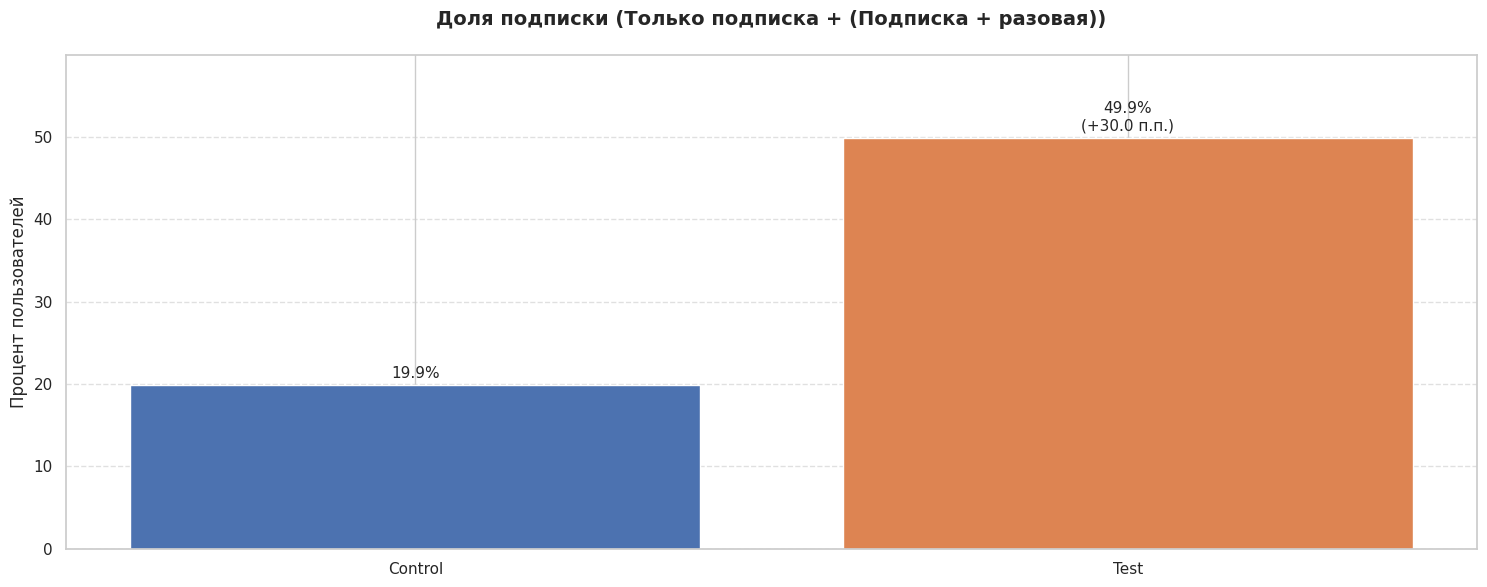

In [ ]:
# Доля подписки

subscription_segments = ['Только подписка', 'Подписка + разовая']


control_count = df_user[(df_user['Group']=='Old') & (df_user['segment_name'].isin(subscription_segments))]['uid'].nunique()
test_count = df_user[(df_user['Group']=='New') & (df_user['segment_name'].isin(subscription_segments))]['uid'].nunique()

control_total = df_user[df_user['Group']=='Old']['uid'].nunique()
test_total = df_user[df_user['Group']=='New']['uid'].nunique()

control_share = control_count / control_total * 100
test_share = test_count / test_total * 100
diff_pp = test_share - control_share

x = [0, 1]
shares = [control_share, test_share]
groups = ['Control', 'Test']

fig, ax = plt.subplots()

ax.bar(x, shares, color=[PALETTE["control"], PALETTE["test"]])

ax.text(x[0], shares[0] + 0.5, f'{shares[0]:.1f}%', ha='center', va='bottom')
ax.text(x[1], shares[1] + 0.5, f'{shares[1]:.1f}%\n({diff_pp:+.1f} п.п.)', ha='center', va='bottom')

ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('Процент пользователей')
ax.set_title('Доля подписки (Только подписка + (Подписка + разовая))\n')
ax.set_ylim(0, max(shares) + 10)
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# Проверка стат значимости доли подписки (хи-квадрат)

subscription_segments = ['Только подписка','Подписка + разовая']

subs = df_user[df_user['segment_name'].isin(subscription_segments)].groupby('Group')['uid'].nunique()
total = df_user.groupby('Group')['uid'].nunique()

control_count = subs['Old']
test_count = subs['New']
control_total = total['Old']
test_total = total['New']

control_share = control_count / control_total
test_share = test_count / test_total

contingency_table = np.array([
    [test_count, control_count],
    [test_total - test_count, control_total - control_count]
])

chi2, p_value_chi2, dof, expected = chi2_contingency(contingency_table)

ci_lower_group, ci_upper_group = proportion_confint(
    count=[control_count, test_count],
    nobs=[control_total, test_total],
    alpha=0.05, method='normal'
)

diff = test_share - control_share
se_diff = np.sqrt(test_share*(1-test_share)/test_total + control_share*(1-control_share)/control_total)
ci_lower_diff = diff - 1.96*se_diff
ci_upper_diff = diff + 1.96*se_diff


print("Доля подписчиков по группам с 95% CI:")
for grp, share, ci_low, ci_up in zip(['Control','Test'], [control_share, test_share], ci_lower_group, ci_upper_group):
    print(f"{grp}: доля = {share:.3f}, 95% CI = ({ci_low:.3f}, {ci_up:.3f}) ")

print(f"\nРазница долей (Test - Control):  {diff:.3f}")
print(f"95% доверительный интервал: ({ci_lower_diff:.3f}, {ci_upper_diff:.3f})")
print(f"Chi-square = {chi2:.2f}, p-value = {p_value_chi2:.4f}")

Доля подписчиков по группам с 95% CI:
Control: доля = 0.199, 95% CI = (0.194, 0.204) 
Test: доля = 0.499, 95% CI = (0.493, 0.505) 

Разница долей (Test - Control):  0.300
95% доверительный интервал: (0.292, 0.308)
Chi-square = 4953.73, p-value = 0.0000


Вывод:

1. Ключевая метрика гипотезы — доля подписчиков:

В контрольной группе доля подписчиков составляет 19,9%, в тестовой — 49,9%, разница +30 п.п.

95% доверительный интервал для разницы: [29,2%; 30,8%], p-value = 0, что подтверждает статистическую и практическую значимость эффекта.

2. Разбивка по сегментам:

- “Только подписка”: рост доли пользователей +18,7 п.п.

- “Подписка + разовая”: рост +11,3 п.п.

- “Только разовые покупки”: снижение доли -11,2 п.п.

- “Без платежей”: снижение доли -18,8 п.п.

Все сегменты имеют  p-value = 0, что подтверждает статистическую значимость изменений.

Пользователи в тестовой группе активно переходят в подписочные сегменты, одновременно снижается доля неплатящих и пользователей с разовыми покупками, что логично в рамках A/B-гипотезы — продукт стимулирует конверсию в подписку.

A/B-тест показывает очевидный и сильный эффект на ключевую метрику, рост подписчиков почти в 2,5 раза по сравнению с контрольной группой.

#### Метрики платежности

In [ ]:
# Общие платежные метрики на всех пользователей

summary = df_user.groupby('Group').agg(
    users=('uid','nunique'),
    payers=('paying','sum'),
    revenue=('total_revenue','sum'),
    total_payments=('payments_count','sum')
).reset_index()

summary['conversion'] = summary['payers'] / summary['users']
summary['ARPU'] = summary['revenue'] / summary['users']
summary['ARPPU'] = summary['revenue'] / summary['payers']
summary['AOV'] = summary['revenue'] / summary['total_payments']

summary = summary[['Group','users','payers','conversion','revenue','ARPU','ARPPU','total_payments','AOV']]
summary

,Group,users,payers,conversion,revenue,ARPU,ARPPU,total_payments,AOV
0,New,25000,17119,0.68476,3860640.0,154.425600,225.517846,21797.0,177.117952
1,Old,25001,12411,0.49642,3845800.0,153.825847,309.870276,14261.0,269.672533


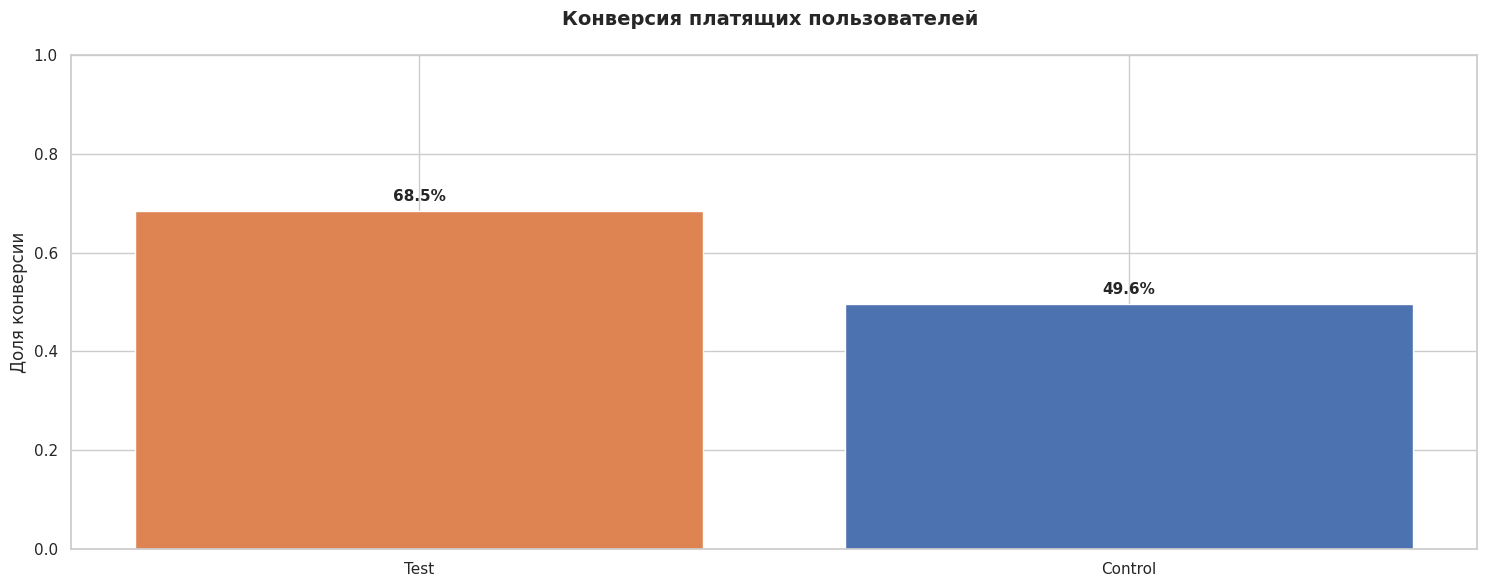

In [ ]:
# Конверсия платящих пользователей

groups = summary['Group']
conversion = summary['conversion']

colors = [PALETTE["control"] if g == "Old" else PALETTE["test"] for g in groups]

fig, ax = plt.subplots()

ax.bar(['Test', 'Control'], conversion, color=colors)
ax.set_ylabel('Доля конверсии')
ax.set_title('Конверсия платящих пользователей \n')

ax.set_ylim(0, 1)

for i, v in enumerate(conversion):
    ax.text(i, v + 0.02, f'{v*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Проверка стат значимости  конверсии в покупку (хи-квадрат)

control_total = df_user[df_user['Group']=='Old']['uid'].nunique()
test_total = df_user[df_user['Group']=='New']['uid'].nunique()

control_conv = df_user[(df_user['Group']=='Old') & (df_user['paying']==1)]['uid'].nunique()
test_conv = df_user[(df_user['Group']=='New') & (df_user['paying']==1)]['uid'].nunique()

contingency = np.array([
    [test_conv, control_conv],
    [test_total - test_conv, control_total - control_conv]
])

chi2, p_value, dof, expected = chi2_contingency(contingency)

control_rate = control_conv / control_total
test_rate = test_conv / test_total
diff = test_rate - control_rate

se_diff = np.sqrt(test_rate*(1-test_rate)/test_total + control_rate*(1-control_rate)/control_total)
ci_lower = diff - 1.96*se_diff
ci_upper = diff + 1.96*se_diff


print(f"Conversion Control: {control_rate:.3f}")
print(f"Conversion Test: {test_rate:.3f}")
print(f"Diff (Test - Control): {diff:.3f}")
print(f"95% CI: ({ci_lower:.3f}, {ci_upper:.3f})")
print(f"Chi2 = {chi2:.2f}, p-value = {p_value:.4e}")

Conversion Control: 0.496
Conversion Test: 0.685
Diff (Test - Control): 0.188
95% CI: (0.180, 0.197)
Chi2 = 1833.05, p-value = 0.0000e+00


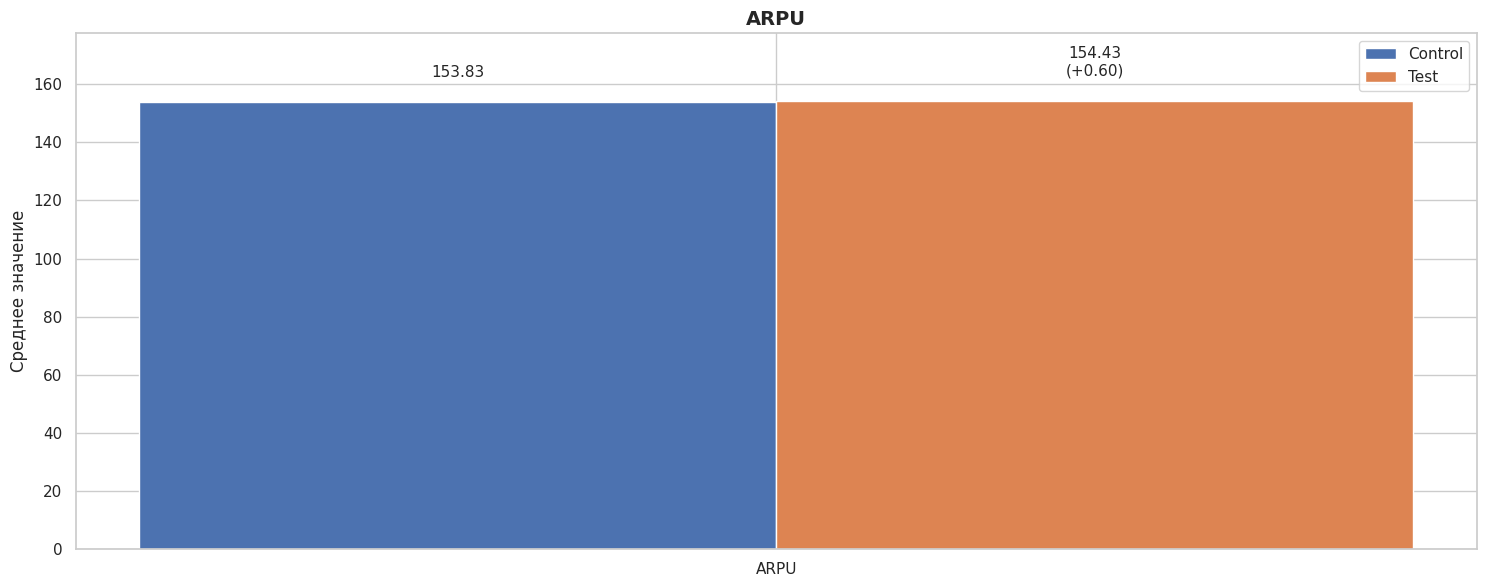

In [ ]:
# Метрика ARPU

metrics = ['ARPU']
x = np.arange(len(metrics))
width = 0.35

old_values = summary.loc[summary['Group']=='Old', metrics].values.flatten()
new_values = summary.loc[summary['Group']=='New', metrics].values.flatten()

fig, ax = plt.subplots()

ax.bar(x - width/2, old_values, width, label='Control', color=PALETTE["control"])
ax.bar(x + width/2, new_values, width, label='Test', color=PALETTE["test"])

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Среднее значение')
ax.set_title('ARPU')
ax.legend()

offset = max(max(old_values), max(new_values)) * 0.05

for i in range(len(metrics)):
    diff = new_values[i] - old_values[i]

    ax.text(i - width/2, old_values[i] + offset, f'{old_values[i]:.2f}', ha='center', va='bottom')
    ax.text(i + width/2, new_values[i] + offset, f'{new_values[i]:.2f}\n({diff:+.2f})', ha='center', va='bottom')

ax.set_ylim(0, max(max(old_values), max(new_values)) * 1.15)

plt.tight_layout()
plt.show()

In [ ]:
# Проверка стат значимости ARPU (t-test)

control = df_user[df_user['Group']=='Old']
test = df_user[df_user['Group']=='New']

control_data = control['total_revenue']
test_data = test['total_revenue']

control_mean = control_data.mean()
test_mean = test_data.mean()

diff = test_mean - control_mean
diff_pct = (diff / control_mean * 100) if control_mean != 0 else np.nan

cm = sm.stats.CompareMeans(
    sm.stats.DescrStatsW(test_data),
    sm.stats.DescrStatsW(control_data)
)
ci_low, ci_up = cm.tconfint_diff()

stat, p_value = ttest_ind(test_data, control_data, equal_var=False)

print("ARPU: ")
print(f"Control: {control_mean:.2f}")
print(f"Test: {test_mean:.2f}")
print(f"Разница (Test-Control): {diff:.2f} ({diff_pct:+.1f}%)")
print(f"95% CI: ({ci_low:.2f}, {ci_up:.2f})")
print(f"p-value: {p_value:.4f}")


ARPU: 
Control: 153.83
Test: 154.43
Разница (Test-Control): 0.60 (+0.4%)
95% CI: (-2.19, 3.39)
p-value: 0.6735


#### Метрики платежности (по сегментам)


In [ ]:
# Метрики платежности по сегментам

segments = df_user['segment_name'].unique()
results = []

for seg in segments:

    control = df_user[(df_user['Group']=='Old') & (df_user['segment_name']==seg)]
    test = df_user[(df_user['Group']=='New') & (df_user['segment_name']==seg)]

    control_users = len(control)
    test_users = len(test)

    revenue_control = control['total_revenue'].sum()
    revenue_test = test['total_revenue'].sum()
    revenue_diff_pct = ((revenue_test - revenue_control) / revenue_control * 100) if revenue_control != 0 else 0

    ARPU_control = control['total_revenue'].mean()
    ARPU_test = test['total_revenue'].mean()
    ARPU_diff_pct = ((ARPU_test - ARPU_control) / ARPU_control * 100) if ARPU_control != 0 else 0

    total_payments_control = control['payments_count'].sum()
    total_payments_test = test['payments_count'].sum()
    total_payments_diff_pct = ((total_payments_test - total_payments_control) / total_payments_control * 100) if total_payments_control != 0 else 0

    AOV_control = control[control['paying']==1]['aov'].mean() if not control[control['paying']==1].empty else 0
    AOV_test = test[test['paying']==1]['aov'].mean() if not test[test['paying']==1].empty else 0
    AOV_diff_pct = ((AOV_test - AOV_control) / AOV_control * 100) if AOV_control != 0 else 0

    # Добавляем в таблицу
    results.append({
        'Сегмент': seg,
        'Users Control': control_users,
        'Users Test': test_users,
        'Revenue Control': round(revenue_control,2),
        'Revenue Test': round(revenue_test,2),
        'Revenue Diff (%)': f"{revenue_diff_pct:+.1f}%",
        'ARPU Control': round(ARPU_control,2),
        'ARPU Test': round(ARPU_test,2),
        'ARPU Diff (%)': f"{ARPU_diff_pct:+.1f}%",
        'Total Payments Control': total_payments_control,
        'Total Payments Test': total_payments_test,
        'Total Payments Diff (%)': f"{total_payments_diff_pct:+.1f}%",
        'AOV Control': round(AOV_control,2),
        'AOV Test': round(AOV_test,2),
        'AOV Diff (%)': f"{AOV_diff_pct:+.1f}%"
    })

segment_table = pd.DataFrame(results)
segment_table = segment_table.sort_values('Сегмент').reset_index(drop=True)
segment_table

,Сегмент,Users Control,Users Test,Revenue Control,Revenue Test,Revenue Diff (%),ARPU Control,ARPU Test,ARPU Diff (%),Total Payments Control,Total Payments Test,Total Payments Diff (%),AOV Control,AOV Test,AOV Diff (%)
0,Без платежей,12590,7881,0.0,0.0,+0.0%,0.0,0.0,+0.0%,0.0,0.0,+0.0%,0.0,0.0,+0.0%
1,Подписка + разовая,1850,4678,1110000.0,1684080.0,+51.7%,600.0,360.0,-40.0%,3700.0,9356.0,+152.9%,300.0,180.0,-40.0%
2,Только подписка,3118,7791,1247200.0,1246560.0,-0.1%,400.0,160.0,-60.0%,3118.0,7791.0,+149.9%,400.0,160.0,-60.0%
3,Только разовые покупки,7443,4650,1488600.0,930000.0,-37.5%,200.0,200.0,+0.0%,7443.0,4650.0,-37.5%,200.0,200.0,+0.0%


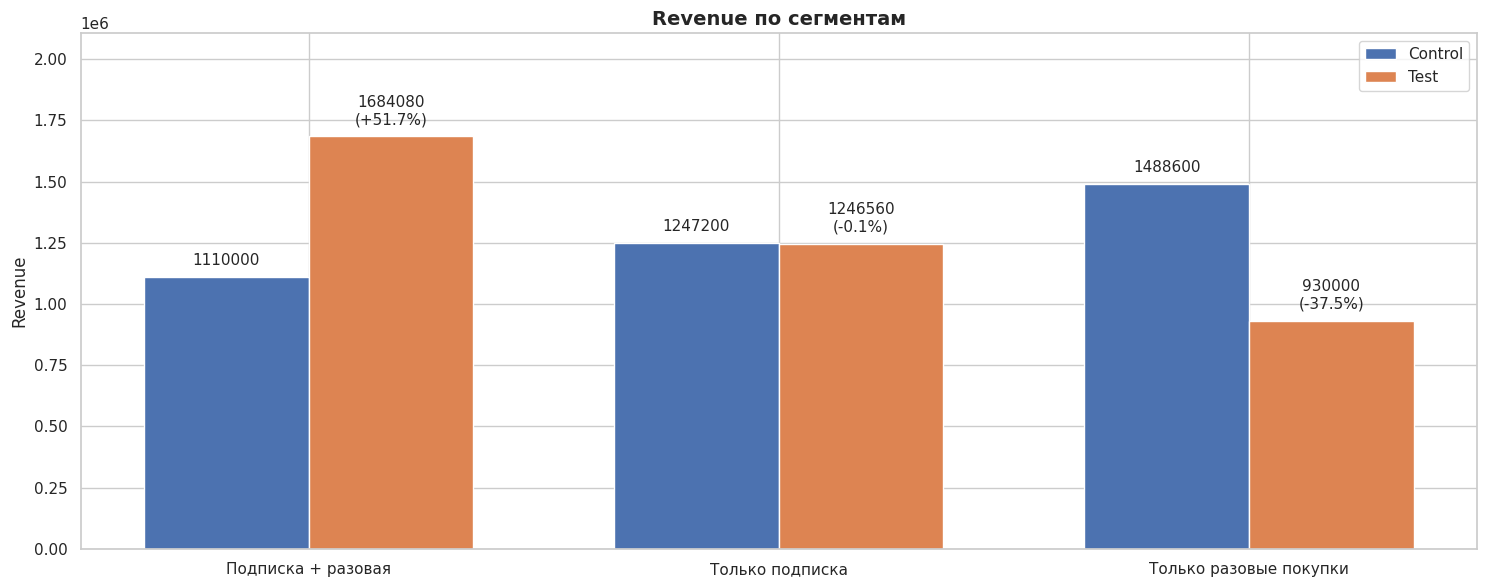

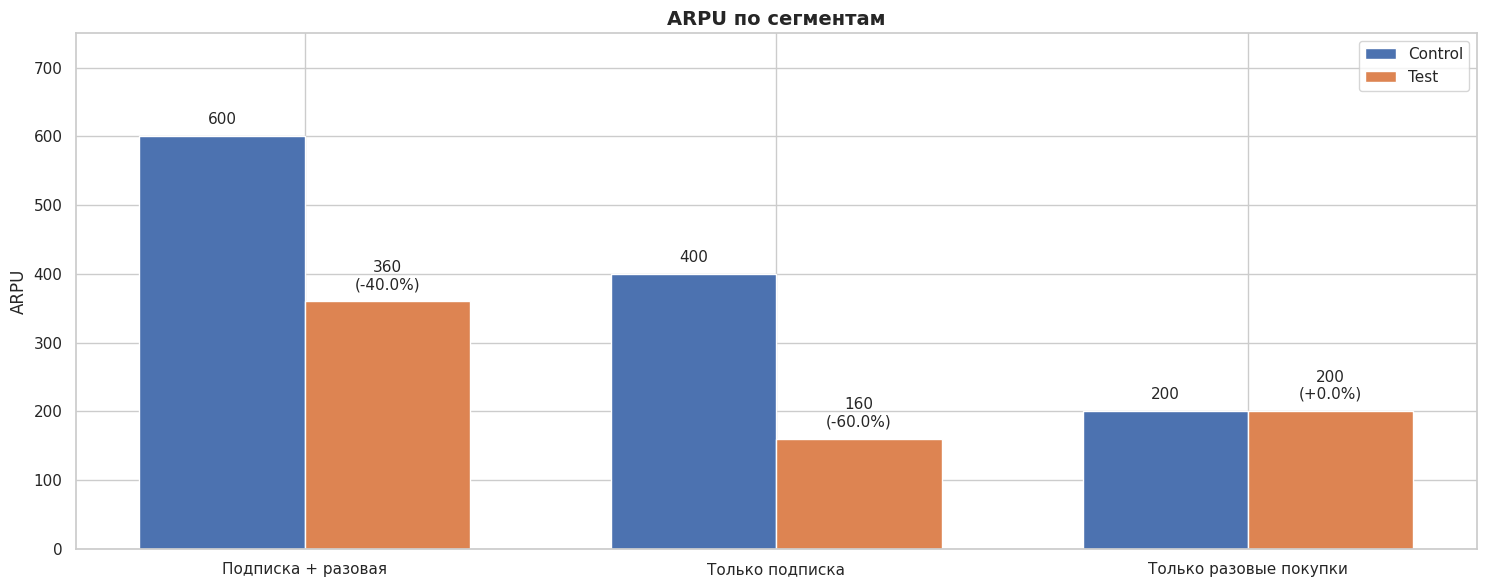

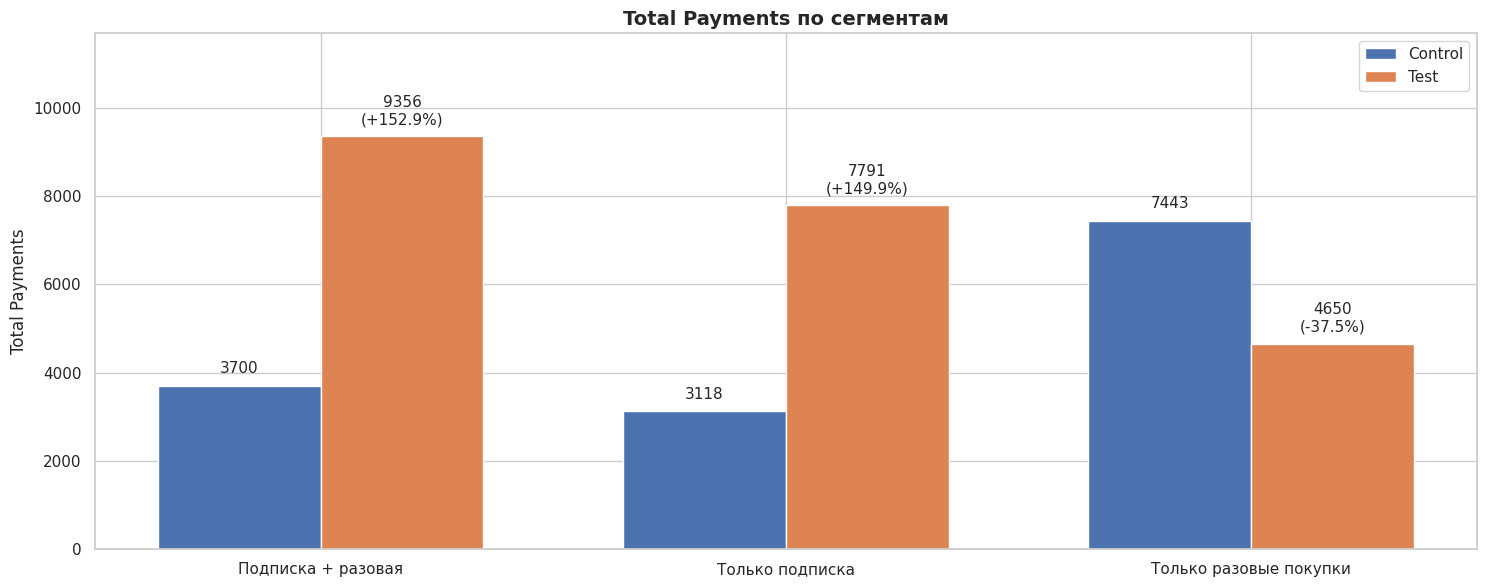

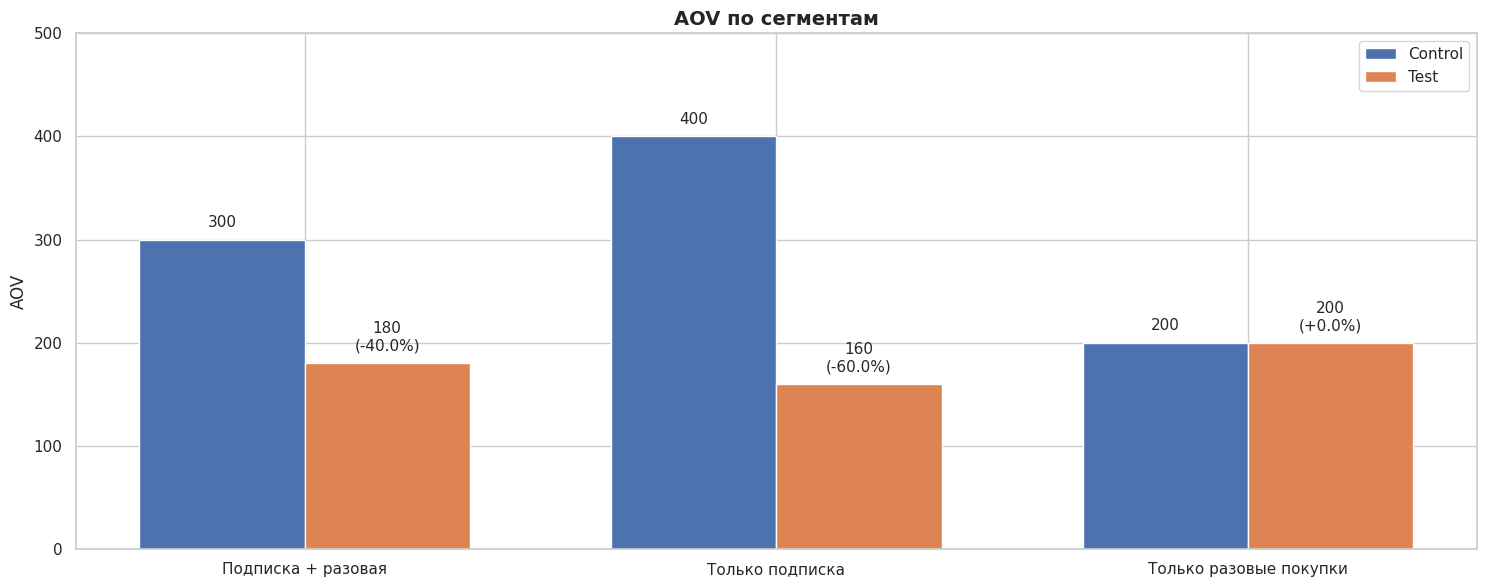

In [ ]:
# Графики метрик платежности по сегментам

segment_table = segment_table[segment_table['Сегмент'] != 'Без платежей'].reset_index(drop=True)

segments = segment_table['Сегмент']
x = np.arange(len(segments))
width = 0.35
metrics = ['Revenue', 'ARPU', 'Total Payments', 'AOV']

for metric in metrics:

    fig, ax = plt.subplots()

    control_vals = segment_table[f'{metric} Control']
    test_vals = segment_table[f'{metric} Test']

    ax.bar(x - width/2, control_vals, width, label='Control', color=PALETTE["control"])
    ax.bar(x + width/2, test_vals, width, label='Test', color=PALETTE["test"])


    ax.set_xticks(x)
    ax.set_xticklabels(segments)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} по сегментам')
    ax.legend()

    max_val = max(control_vals.max(), test_vals.max())
    ax.set_ylim(0, max_val * 1.25)
    offset = max_val * 0.03

    for i in range(len(segments)):
        diff_pct = segment_table[f'{metric} Diff (%)'][i]

        ax.text(i - width/2,
                control_vals[i] + offset,
                f'{control_vals[i]:.0f}',
                ha='center')

        ax.text(i + width/2,
                test_vals[i] + offset,
                f'{test_vals[i]:.0f}\n({diff_pct})',
                ha='center')

    plt.tight_layout()
    plt.show()

In [ ]:
# Проверка на стат значимость ARPU  по сегментам (t-test и FDR (Benjamini–Hochberg))

segments = df_user[
    df_user['segment_name'] != 'Без платежей'
]['segment_name'].unique()

ci_results = []
raw_pvalues = []

for segment in segments:

    control = df_user[
        (df_user['Group'] == 'Old') &
        (df_user['segment_name'] == segment)
    ]['total_revenue']

    test = df_user[
        (df_user['Group'] == 'New') &
        (df_user['segment_name'] == segment)
    ]['total_revenue']

    if len(control) > 1 and len(test) > 1:

        stat, pvalue = ttest_ind(test, control, equal_var=False)

        cm = sm.stats.CompareMeans(
            sm.stats.DescrStatsW(test),
            sm.stats.DescrStatsW(control)
        )
        ci_low, ci_up = cm.tconfint_diff(alpha=0.05)

    else:
        pvalue, ci_low, ci_up = np.nan, np.nan, np.nan

    raw_pvalues.append(pvalue)

    ci_results.append({
        'segment_name': segment,
        'CI_95%_low': round(ci_low, 2),
        'CI_95%_up': round(ci_up, 2),
        'p_value_raw': pvalue
    })

ci_table = pd.DataFrame(ci_results)

valid_mask = ci_table['p_value_raw'].notna()

adjusted = multipletests(
    ci_table.loc[valid_mask, 'p_value_raw'],
    alpha=0.05,
    method='fdr_bh'
)

ci_table.loc[valid_mask, 'p_value_adj'] = adjusted[1]
ci_table.loc[valid_mask, 'significant_adj'] = adjusted[0]

ci_table['p_value_raw'] = ci_table['p_value_raw'].round(4)
ci_table['p_value_adj'] = ci_table['p_value_adj'].round(4)

ci_table = ci_table.sort_values('segment_name').reset_index(drop=True)

ci_table

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,segment_name,CI_95%_low,CI_95%_up,p_value_raw,p_value_adj,significant_adj
0,Подписка + разовая,-240.0,-240.0,0.0,0.0,True
1,Только подписка,-240.0,-240.0,0.0,0.0,True
2,Только разовые покупки,0.0,0.0,NaN,NaN,NaN


In [ ]:
# Проверка на стат значимость AOV по сегментам (бутстреп и FDR (Benjamini–Hochberg))

segments = df_user[
    df_user['segment_name'] != 'Без платежей'
]['segment_name'].unique()

aov_results = []
raw_pvalues = []

n_boot = 10000

for segment in segments:

    control = df_user[
        (df_user['Group'] == 'Old') &
        (df_user['segment_name'] == segment) &
        (df_user['paying'] == 1)
    ]['aov'].values

    test = df_user[
        (df_user['Group'] == 'New') &
        (df_user['segment_name'] == segment) &
        (df_user['paying'] == 1)
    ]['aov'].values

    if len(control) > 1 and len(test) > 1:

        boot_diffs = []

        for _ in range(n_boot):
            boot_control = np.random.choice(control, size=len(control), replace=True)
            boot_test = np.random.choice(test, size=len(test), replace=True)

            boot_diff = boot_test.mean() - boot_control.mean()
            boot_diffs.append(boot_diff)

        boot_diffs = np.array(boot_diffs)

        ci_low = np.percentile(boot_diffs, 2.5)
        ci_up = np.percentile(boot_diffs, 97.5)

        p_value = 2 * min(
            np.mean(boot_diffs <= 0),
            np.mean(boot_diffs >= 0)
        )

    else:
        ci_low, ci_up, p_value = np.nan, np.nan, np.nan

    raw_pvalues.append(p_value)

    aov_results.append({
        'segment_name': segment,
        'AOV_diff_mean': round(test.mean() - control.mean(), 2)
                          if len(control)>1 and len(test)>1 else np.nan,
        'CI_95%_low': round(ci_low, 2),
        'CI_95%_up': round(ci_up, 2),
        'p_value_raw': p_value
    })

aov_ci_table = pd.DataFrame(aov_results)


valid_mask = aov_ci_table['p_value_raw'].notna()

adjusted = multipletests(
    aov_ci_table.loc[valid_mask, 'p_value_raw'],
    alpha=0.05,
    method='fdr_bh'
)

aov_ci_table.loc[valid_mask, 'p_value_adj'] = adjusted[1]
aov_ci_table.loc[valid_mask, 'significant_adj'] = adjusted[0]


aov_ci_table['p_value_raw'] = aov_ci_table['p_value_raw'].round(4)
aov_ci_table['p_value_adj'] = aov_ci_table['p_value_adj'].round(4)

aov_ci_table = aov_ci_table.sort_values('segment_name').reset_index(drop=True)

aov_ci_table

,segment_name,AOV_diff_mean,CI_95%_low,CI_95%_up,p_value_raw,p_value_adj,significant_adj
0,Подписка + разовая,-120.0,-120.0,-120.0,0.0,0.0,True
1,Только подписка,-240.0,-240.0,-240.0,0.0,0.0,True
2,Только разовые покупки,0.0,0.0,0.0,2.0,1.0,False


Общие метрики и конверсия

* Конверсия платящих пользователей  в тестовой группе 68.5%, а в контрольной -  49.6% (+18.8 п.п.), и статистически значимо.
Эксперимент эффективно увеличивает долю платящих пользователей.

* ARPU осталась практически неизменной: 153.83 → 154.43 (+0.4%).
Средний доход на пользователя не изменился, несмотря на рост числа платящих, что указывает на приход новых пользователей с низким платежным поведением.

Сегментный анализ

* Подписка + разовая:
Выручка в тестовой группе выросла на 51.7%, при этом ARPU и AOV статистически значимо снизилось на 40%.
Количество транзакций увеличилось на 152%, что показывает, что цена подписки в 160 не мешает пользователям сначала покупать разовую за 200, а затем подписку за 160, даже если подписка дешевле разовой.
Рост выручки обеспечен увеличением числа платящих и транзакций, при этом новые пользователи имеют меньший средний чек, что снижает ARPU и AOV.

* Только подписка:
Выручка практически не изменилась, несмотря на значительный рост числа пользователей и транзакций. ARPU и AOV статитистически значимо снизилось на 60%.
Рост числа пользователей и транзакций компенсируется низкой ценностью новых платящих, поэтому общая выручка остаётся стабильной.

* Только разовые покупки:
Выручка в тестовой группе снизилась на 37.5%, ARPU и AOV не изменились. Снижение связано с уменьшением числа пользователей и транзакций, средний чек на пользователя остаётся стабильным.

Основной вывод: Эксперимент успешно увеличивает количество платящих пользователей в сегментах с подпиской, однако новые пользователи имеют низкий средний чек и доход на пользователя. В результате общий ARPU остаётся на прежнем уровне, несмотря на значительный рост конверсии.

## Итоговый вывод по A/B-тесту «paymentChange»


1. Конверсия и общий эффект

Эксперимент привёл к значимому росту конверсии платящих пользователей:
49,6% → 68,5% (+18,8 п.п., p < 0.001). Это подтверждает высокую чувствительность пользователей к изменению ценового предложения.

При этом ARPU остался практически неизменным: 153,8 → 154,4 (+0,4%). Несмотря на приток новых платящих пользователей, общий доход на пользователя не вырос, что указывает на перераспределение платежности — рост числа платящих компенсируется снижением их средней ценности.

Важно, что поведенческие метрики не изменились: среднее число действий, скорость прохождения сценариев и интервалы между действиями остались на прежнем уровне. Это означает, что изменение цены не повлияло на вовлечённость и глубину использования продукта.

2. Сегментный анализ

* Подписка + разовая

Сегмент продемонстрировал наиболее выраженную динамику:

количество транзакций увеличилось на 152%;

выручка выросла на 51,7%;

при этом ARPU и AOV снизились примерно на 40%.

Рост обеспечен масштабом — увеличением числа пользователей и транзакций. При этом пользователи продолжают комбинировать модели оплаты: сначала совершают разовую покупку за 200, затем оформляют подписку за 160. Это подтверждает, что более низкая цена подписки не каннибализирует разовые платежи и не является барьером входа в подписку. Наоборот  усиливает транзакционную активность.

* Только подписка

Выручка в сегменте осталась практически неизменной, несмотря на рост числа пользователей и транзакций.
ARPU и AOV снизились примерно на 60%, что говорит о притоке пользователей с более низкой платежной ценностью. Масштаб приводит к снижению среднего чека, но не приводит к росту общей выручки.

* Только разовые покупки

Выручка снизилась на 37,5% за счёт уменьшения числа пользователей и транзакций.
При этом ARPU и AOV остались стабильными, что говорит об отсутствии изменений в поведении ядра этого сегмента.

3. Доля подписчиков

Эксперимент существенно изменил структуру монетизации:

- доля подписчиков выросла почти в 2,5 раза — 49,9% в тесте против 19,9% в контроле (+30 п.п., p < 0.001);

- одновременно снизилась доля неплатящих пользователей и пользователей с исключительно разовыми покупками.

Таким образом, эксперимент не только увеличил конверсию, но и стратегически сместил модель монетизации в сторону подписки. При этом ключевой компромисс эксперимента заключается в следующем: рост масштаба платящей базы сопровождается снижением её средней ценности, что потенциально может повлиять на долгосрочный LTV новых подписчиков.


## Рекомендации


**1.** 1. Полное масштабирование эксперимента — преждевременно

Полное внедрение новой цены для всех пользователей на данном этапе не рекомендуется.

Эксперимент значительно увеличивает конверсию и долю подписчиков, однако сопровождается снижением AOV и ARPPU за счёт притока менее ценных пользователей.

Перед масштабированием необходимо дополнительно оценить:

- LTV новых подписчиков;

- retention;

- повторные платежи;

- churn rate.

Без анализа долгосрочного поведения существует риск снижения выручки в перспективе.

**2.** Сегментная ценовая стратегия вместо массового снижения

Результаты теста показывают, что цена 160:

- не является барьером входа в подписку;
- не мешает пользователям комбинировать разовую оплату (200) и подписку (160).

При этом массовое снижение цены для всей аудитории приводит к снижению AOV и ARPPU за счёт притока менее ценных пользователей и потенциально размывает среднюю ценность платящей базы.

Наибольший потенциал выявлен в сегменте пользователей, уже совершивших разовую покупку. Переход «разовая → подписка» продемонстрировал рост транзакций на 152% и высокую готовность к оформлению подписки.

Рекомендуется сфокусироваться на сегментном подходе:

- предлагать подписку со скидкой после разовой покупки;

- использовать персонализированные предложения;

- тестировать ограниченные по времени предложения (24–72 часа после оплаты разовой).

Такой подход позволит стимулировать переход в подписку точечно, работать с наиболее прогретой и качественной аудиторией и повышать конверсию в оплату и подписку без необходимости снижать цену для всей пользовательской базы.


# SRM

In [ ]:
df.groupby('Group', as_index=False)\
  .agg(uid_uniq = ('uid', 'nunique'))\
  .assign(share =lambda x: x['uid_uniq'] / x['uid_uniq'].sum())

,Group,uid_uniq,share
0,New,25000,0.49999
1,Old,25001,0.50001


# Нахождение перетекание пользователей между группами в рамках одного эксперимента

In [ ]:
df.groupby('uid', as_index=False)\
  .agg(group_count=('Group', 'nunique'))\
  .query('group_count > 1').uid.count()

np.int64(0)

# Нахождение пересечения с другими экспериментами

In [ ]:
df_group.head()

,Experiment,Group,uid
0,actionChange,Old,cfjqq
1,actionChange,Old,hclau
2,actionChange,Old,bkhtq
3,actionChange,Old,rxxdh
4,actionChange,Old,ccsko


In [ ]:
df_group.shape

(100002, 3)

In [ ]:
df_group.Experiment.unique()

array(['actionChange', 'paymentChange'], dtype=object)

In [ ]:
df_merged = df.merge(df_group[['uid', 'Experiment' ]], on='uid', how='left')

df_merged.head()

,uid,Ts,Action,open_ts,delta_ts,delta_hours,prev_ts,delta_prev_ts,delta_prev_hours,Group,total_revenue,payments_count,aov,segment_name,paying,Experiment
0,aaago,2020-01-16 22:01:51,firstOpen,2020-01-16 22:01:51,0 days 00:00:00,0.00,NaT,NaT,NaN,Old,400.0,1.0,400.0,Только подписка,1,actionChange
1,aaago,2020-01-16 22:01:51,firstOpen,2020-01-16 22:01:51,0 days 00:00:00,0.00,NaT,NaT,NaN,Old,400.0,1.0,400.0,Только подписка,1,paymentChange
2,aaago,2020-01-17 13:24:32,function1,2020-01-16 22:01:51,0 days 15:22:41,15.38,2020-01-16 22:01:51,0 days 15:22:41,15.378056,Old,400.0,1.0,400.0,Только подписка,1,actionChange
3,aaago,2020-01-17 13:24:32,function1,2020-01-16 22:01:51,0 days 15:22:41,15.38,2020-01-16 22:01:51,0 days 15:22:41,15.378056,Old,400.0,1.0,400.0,Только подписка,1,paymentChange
4,aaago,2020-01-17 13:38:16,function4,2020-01-16 22:01:51,0 days 15:36:25,15.61,2020-01-17 13:24:32,0 days 00:13:44,0.228889,Old,400.0,1.0,400.0,Только подписка,1,actionChange


In [ ]:
df_merged.shape

(370378, 16)

In [ ]:
df_merged.groupby('uid', as_index=False) \
        .agg(exp_count=('Experiment', 'nunique')) \
        .query('exp_count > 1') \
        .uid.count()

np.int64(50001)

Все 50 001 пользователей участвуют в двух экспериментах одновременно.

То есть каждый uid присутствует и в paymentChange, и в actionChange.

# Оценка влияния двух экспериментов одновременно

In [ ]:
df_exp = df_group.pivot(index='uid', columns='Experiment', values='Group').reset_index()
df_exp.head()

Experiment,uid,actionChange,paymentChange
0,aaago,New,Old
1,aaahw,Old,New
2,aaaii,Old,New
3,aaaim,Old,New
4,aaaop,Old,Old


In [ ]:
df_exp['paymentChange'] = (df_exp['paymentChange'] == 'New').astype(int)
df_exp['actionChange'] = (df_exp['actionChange'] == 'New').astype(int)

In [ ]:
df_exp.head()

Experiment,uid,actionChange,paymentChange
0,aaago,1,0
1,aaahw,0,1
2,aaaii,0,1
3,aaaim,0,1
4,aaaop,0,0


In [ ]:
df_exp.shape

(50001, 3)

In [ ]:
# Берем сегмент для каждого пользователя

df_segment = df_pay_exp.groupby('uid', as_index=False).agg(segment_name=('segment_name', 'first'))
df_segment.shape

(29530, 2)

In [ ]:
df = df_exp.merge(df_segment[['uid','segment_name']], on = 'uid', how='left')

df['segment_name'] = df['segment_name'].fillna('Без платежей')

df.head()

,uid,actionChange,paymentChange,segment_name
0,aaago,1,0,Только подписка
1,aaahw,0,1,Без платежей
2,aaaii,0,1,Подписка + разовая
3,aaaim,0,1,Без платежей
4,aaaop,0,0,Без платежей


In [ ]:
df.shape

(50001, 4)

In [ ]:
# создаём колонку конверсии

df['conversion'] = df['segment_name'].isin(['Только подписка', 'Подписка + разовая']).astype(int)

df.head()

,uid,actionChange,paymentChange,segment_name,conversion
0,aaago,1,0,Только подписка,1
1,aaahw,0,1,Без платежей,0
2,aaaii,0,1,Подписка + разовая,1
3,aaaim,0,1,Без платежей,0
4,aaaop,0,0,Без платежей,0


In [ ]:
# логистическая регрессия

model = smf.logit(
    formula='conversion ~ paymentChange + actionChange + paymentChange:actionChange',
    data=df).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.595855
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:             conversion   No. Observations:                50001
Model:                          Logit   Df Residuals:                    49997
Method:                           MLE   Df Model:                            3
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                 0.07856
Time:                        11:25:16   Log-Likelihood:                -29793.
converged:                       True   LL-Null:                       -32334.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                     -1.4162      0.023    -62.766      0.000      

In [ ]:
# Получаем коэффициенты модели
coef = model.params
OR = np.exp(coef)  # odds ratio

print("Odds Ratios:")
print(OR)

# Рассчитаем вероятности конверсии для всех комбинаций
def logit_to_prob(x):
    return 1 / (1 + np.exp(-x))

# Четыре комбинации 2x2
combinations = pd.DataFrame({
    'paymentChange': [0, 0, 1, 1],
    'actionChange': [0, 1, 0, 1]
})
# Вычисляем линейную часть и вероятность
combinations['linear_pred'] = (coef['Intercept'] +
                               coef['paymentChange']*combinations['paymentChange'] +
                               coef['actionChange']*combinations['actionChange'] +
                               coef['paymentChange:actionChange']*combinations['paymentChange']*combinations['actionChange'])

combinations['conv_prob'] = logit_to_prob(combinations['linear_pred'])
combinations['odds'] = np.exp(combinations['linear_pred'])

print("\nВероятности конверсии и odds по комбинациям:")
combinations

Odds Ratios:
Intercept                     0.242644
paymentChange                 4.123900
actionChange                  1.044262
paymentChange:actionChange    0.946948
dtype: float64

Вероятности конверсии и odds по комбинациям:


,paymentChange,actionChange,linear_pred,conv_prob,odds
0,0,0,-1.416159,0.195264,0.242644
1,0,1,-1.372849,0.202160,0.253384
2,1,0,0.000640,0.500160,1.000640
3,1,1,-0.010560,0.497360,0.989495


Вывод:

- paymentChange: эффект изменения цены подписки.
Интерпретация: если поменять цену , шансы конверсии увеличиваются примерно в 4 раза, p < 0.001 - статистически значимо.

- actionChange: второй эксперимент не оказывает значимого влияния на конверсию.
Эффект почти отсутствует, p = 0.172 - незначимо.

- paymentChange:actionChange: слабое отрицательное взаимодействие  двух экспериментов, p = 0.179 - статистически незначимо. Одновременное применение двух изменений слегка уменьшает эффект, но эффект незначим, можно оценивать каждый эксперимент отдельно.

Итог: эффект изменения цены можно считать чистым, независимым от второго эксперимента. Влияние actionChange и взаимодействия на конверсию статистически не подтверждено.